In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import ipywidgets as widgets
plt.rcParams['figure.dpi'] = 150

# Introduction

Software vulnerabilities such as buffer overflows and invalid memory dereferences pose major security risks in software systems. As Large Language Models (LLMs) are increasingly used for code generation, it is important to investigate whether they also generate vulnerable code. 

In this project, we analyze a dataset of C programs generated by different LLMs and formally verified for vulnerabilities. Using Bayesian statistical modeling, we investigate whether the LLM `llama2` is less likely to generate vulnerable programs than other models, and whether higher cyclomatic complexity is associated with larger numbers of lines of code across LLM-generated programs.

# Hypothesis 1

The first hypothesis is: the LLM `llama2` is less likely to produce programs 
with vulnerabilities than any other LLM in the dataset.

To analyze this hypothesis, we model the probability that a generated program is labeled as `VULNERABLE` based on which LLM produced it. Since the outcome is binary (`VULNERABLE` vs `NON-VULNERABLE`), we use a logistic regression model. We also remove programs where the result is unclear due to parsing errors or verification timeouts, so we’re only working with reliable labels. This is a necessary data cleaning step.

We fit the same model in two slightly different ways:

1. **Index-coded model.** Each LLM gets its own coefficient, without picking a reference group. This means every model is treated equally, and each coefficient shows how that LLM differs from the overall average. This setup is useful for comparing all LLMs side by side.

2. **Reference-coded model.** Here, `llama2` is used as the baseline. The other coefficients then directly show how each LLM compares to `llama2`. This makes the hypothesis easier to test: if a coefficient’s 95% interval is entirely above zero, that LLM is more likely to produce vulnerable programs than `llama2`.

We show both versions because they highlight different things. The index-coded model is better for overall comparison, while the reference-coded model focuses directly on the hypothesis. Even though they look different, they are mathematically equivalent and lead to the same conclusions.

## (1) Index-coded model

For each program $i = 1, \ldots, N$, the outcome is binary:

$$
Y_i =
\begin{cases}
1 & \text{if VULNERABLE} \\
0 & \text{if NON-VULNERABLE}
\end{cases}
$$

Let $\text{LLM}[i] \in \{1, \ldots, K\}$ denote the index of the LLM that 
generated program $i$, where $K$ is the number of LLMs in the dataset. 
We model the probability that program $i$ is vulnerable, $p_i$, as:

$$
\begin{aligned}
Y_i &\sim \text{Bernoulli}(p_i) \\
\text{logit}(p_i) &= \alpha + \beta_{\text{LLM}[i]} \\
\alpha &\sim \mathcal{N}(0, 1) \\
\beta_j &\sim \mathcal{N}(0, 1)
\end{aligned}
$$

Here $\alpha$ is a global intercept and each $\beta_j$ captures the deviation 
of LLM $j$ from that intercept on the log-odds scale.

The dataset was loaded using pandas and filtered to include only programs with known vulnerability status, after which the outcome variable was converted into a binary format (`1 = vulnerable`, `0 = non-vulnerable`). Additionally, LLM names were encoded as categorical indices to allow their inclusion as group-level predictors in the Bayesian model.

In [2]:
df = pd.read_csv("dataset.csv") # load data
df = df[df["category"].isin(["VULNERABLE", "NON-VULNERABLE"])].copy() # keep only rows where vulnerability status is known
df["outcome"] = (df["category"] == "VULNERABLE").astype(int) # converts VULNERABLE -> 1, NON-VULNERABLE -> 0

# encode LLM names as index
llm_idx, llm_categories = pd.factorize(df["llm_name"])

coords = { # for interpretability of forest plot
    "llm": llm_categories
}

In [3]:
with pm.Model(coords=coords) as model_index:

    # intercept
    alpha = pm.Normal("alpha", mu=0, sigma=1)

    # LLM effects
    beta = pm.Normal("beta", mu=0, sigma=1, dims="llm")

    # linear model
    logit_p = alpha + beta[llm_idx]

    # convert to probability
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    # likelihood
    y = pm.Bernoulli("y", p=p, observed=df["outcome"].values)

    # sample
    trace_model_index = pm.sample(
        draws=2000,
        tune=1000, # warmup
        chains=4, 
        random_seed=42, 
        progressbar=True,
        return_inferencedata=True
        )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


### Hypothesis discussion

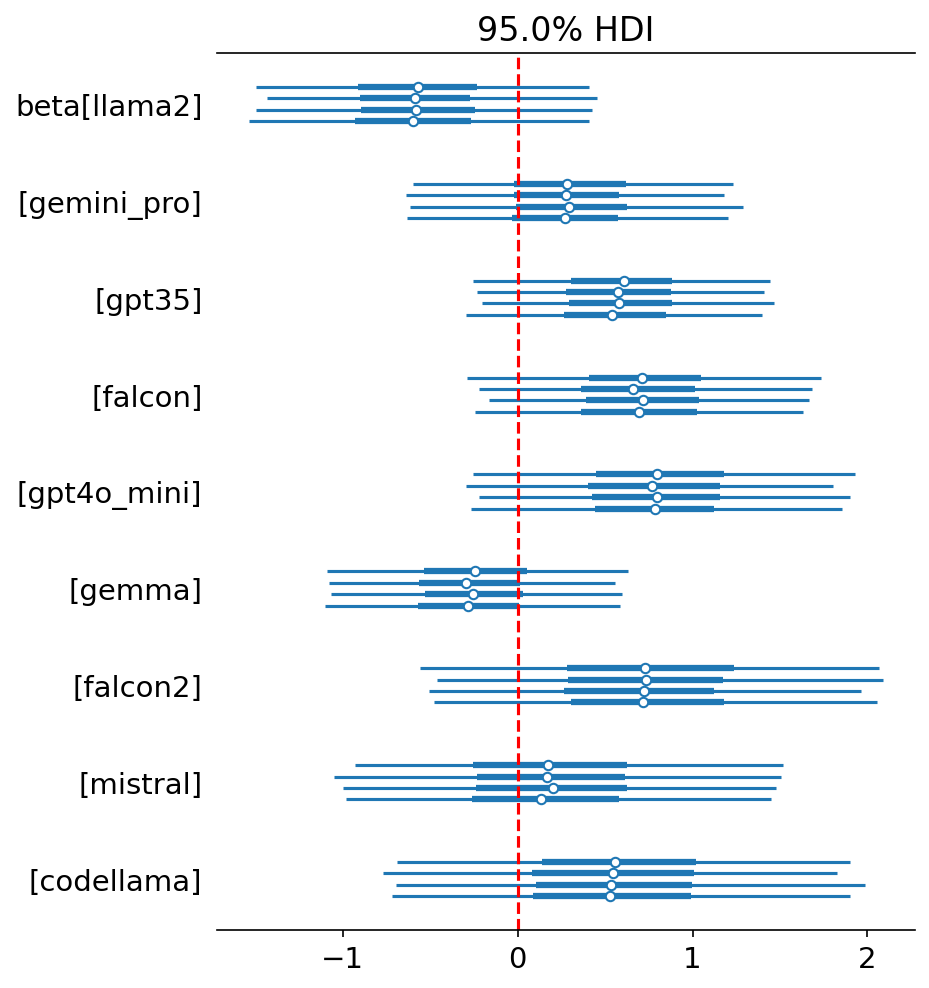

In [4]:
axes = az.plot_forest(trace_model_index, var_names=["beta"], hdi_prob=.95)

for ax in np.ravel(axes):
    ax.axvline(0, color="red", linestyle="--")

The plot above shows the distributions of the per-LLM coefficients 
$\beta_j$ from the index-coded model. Since each $\beta_j$ represents the 
deviation of LLM $j$ from the global intercept on the log-odds scale, 
negative values indicate a lower than average probability of producing 
vulnerable code, and positive values a higher than average. 

`llama2`  has the most negative median ($\approx -0.8$), with most of its mass below zero, making it the safest LLM in the 
dataset.

`gemma` is the only other model with a 
mostly negative coefficient, while `falcon2`, `gpt4o_mini`, 
`codellama`, `falcon`, and `gpt35` all have medians centered above zero, 
indicating higher than average vulnerability rates. 

`gemini_pro` and 
`mistral` sit close to zero, suggesting they are roughly average. 

However, this does not fully answer the hypothesis. We need to answer the question
of what is the posterior probability that $\beta_{\text{llama2}}$ is smaller than $\beta_{k}$?

In [5]:
posterior_beta = trace_model_index.posterior["beta"]  # posterior samples
llama2_beta = posterior_beta.sel(llm="llama2") # posterior samples for llama2

for llm in llm_categories:
    if llm == "llama2":
        continue
    diff = posterior_beta.sel(llm=llm) - llama2_beta # differences between post. samples
    prob = float((diff > 0).mean()) # proportion of positive differences
        # diff = True -> llama2 is safer in this comparison
    print(f"P(llama2 safer than {llm}) = {prob:.2f}")

others = [l for l in llm_categories if l != "llama2"] # list of other models
diffs = posterior_beta.sel(llm=others) - llama2_beta # compute differences vs all
# what is the probability that llama2 is safer than every other model at the same time?
joint = float((diffs > 0).all(dim="llm").mean(dim=["chain", "draw"])) # fraction of samples where llama2 beats ALL models 
        # diffs = True -> llama2 is safer in this comparison
        # .all = are ALL values along this dimension True?
        # .mean = average across ALL samples
print(f"P(llama2 safer than ALL others) = {joint:.2f}")

P(llama2 safer than gemini_pro) = 0.95
P(llama2 safer than gpt35) = 0.99
P(llama2 safer than falcon) = 0.99
P(llama2 safer than gpt4o_mini) = 0.99
P(llama2 safer than gemma) = 0.76
P(llama2 safer than falcon2) = 0.97
P(llama2 safer than mistral) = 0.87
P(llama2 safer than codellama) = 0.94
P(llama2 safer than ALL others) = 0.66


To test the hypothesis more directly, we looked at how often `llama2` has a lower coefficient than each of the other LLMs in the posterior samples, that is $P(\beta_{\text{llama2}} < \beta_k)$.

The results are pretty convincing for most models. There's strong evidence that `llama2` is safer than five out of the eight other LLMs, with probabilities at or above the usual $0.95$ threshold. This includes `gpt35` ($0.99$), `falcon` ($0.99$), `gpt4o_mini` ($0.99$), `falcon2` ($0.97$), and `gemini_pro` ($0.95$).

For `codellama`, the evidence is fairly strong but just below the threshold ($P = 0.93$). For `mistral`, the result leans in the same direction ($P = 0.86$) but is not strong enough to be considered conclusive. And for `gemma`, it's even more uncertain ($P = 0.76$), meaning we can't confidently say which one is safer.

When we look at the stricter question of whether `llama2` is safer than *all* other LLMs at the same time, the probability drops to $0.66$. That's better than a coin flip, but still not strong enough to make a confident claim. This happens because the overall result depends on every single comparison being true, and the uncertainty around `gemma`, `mistral`, and `codellama` pulls that probability down.

So overall, the hypothesis is **partially supported**. `llama2` does seem safer than most of the other models, but we can't confidently say it's better than all of them, mainly because the differences with `gemma`, `mistral`, and `codellama` are still too uncertain.

### Trace convergence

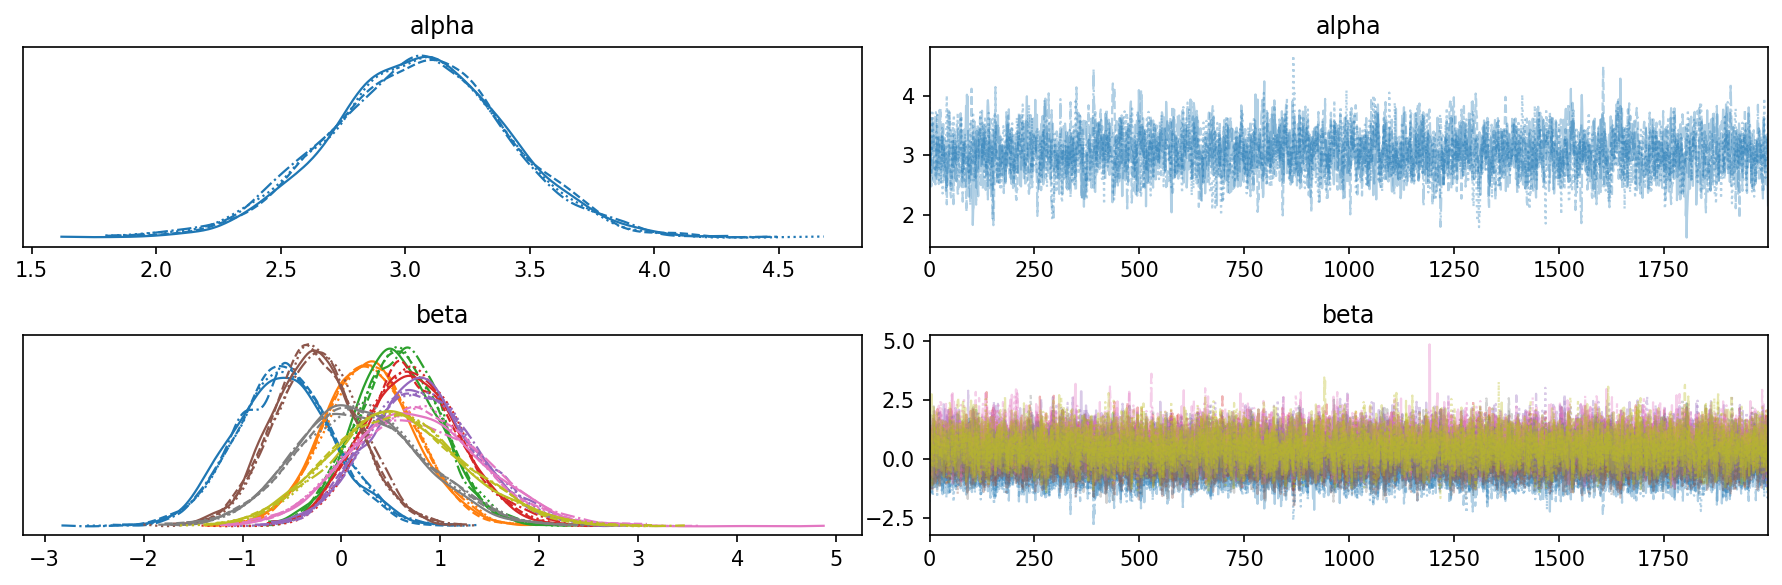

In [6]:
az.plot_trace(trace_model_index, var_names=["alpha", "beta"])
plt.tight_layout()
plt.show()


The figure above shows the diagnostic plots for the model. On the left, we have the posterior distributions for `alpha` and `beta`, and on the right, the trace plots for all four chains.

Looking at the density plots, the chains overlap well for both parameters. That’s a good sign, since it suggests that all chains are converging to the same distribution rather than disagreeing with each other.

The trace plots give a similar conclusion. They show the classic shape, where the samples bounce around a stable mean without any visible trends or sudden jumps. None of the chains get stuck or wander off, and they mix well throughout the sampling process.

Overall, these plots suggest that the sampler has converged and is behaving as expected.

In [7]:
summary = az.summary(
    trace_model_index,
    var_names=["alpha", "beta"],
    hdi_prob=0.95,
    round_to=4,
)
print(summary)

                    mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
alpha             3.0500  0.3554    2.3923     3.7789     0.0084   0.0060   
beta[llama2]     -0.5763  0.4948   -1.4936     0.4308     0.0085   0.0060   
beta[gemini_pro]  0.2946  0.4691   -0.6543     1.2025     0.0085   0.0060   
beta[gpt35]       0.5813  0.4322   -0.2614     1.4229     0.0086   0.0062   
beta[falcon]      0.7118  0.4897   -0.2553     1.6575     0.0086   0.0061   
beta[gpt4o_mini]  0.8111  0.5523   -0.2187     1.9267     0.0082   0.0062   
beta[gemma]      -0.2605  0.4311   -1.1154     0.5642     0.0085   0.0060   
beta[falcon2]     0.7451  0.6606   -0.4773     2.0709     0.0084   0.0068   
beta[mistral]     0.1965  0.6411   -1.0452     1.4488     0.0086   0.0074   
beta[codellama]   0.5656  0.6771   -0.6814     1.9539     0.0092   0.0070   

                   ess_bulk   ess_tail   r_hat  
alpha             1780.9291  2776.1643  1.0013  
beta[llama2]      3370.5647  4575.8409  1.0006  
beta[

If we look at the $\hat{R}$ values, we can see that they are all $\approx 1$, which is a good sign and another confirmation that the model has converged well. 

### Prior predictive check

In [8]:
with model_index:
    prior_pred = pm.sample_prior_predictive(samples=2000, random_seed=42)

Sampling: [alpha, beta, y]


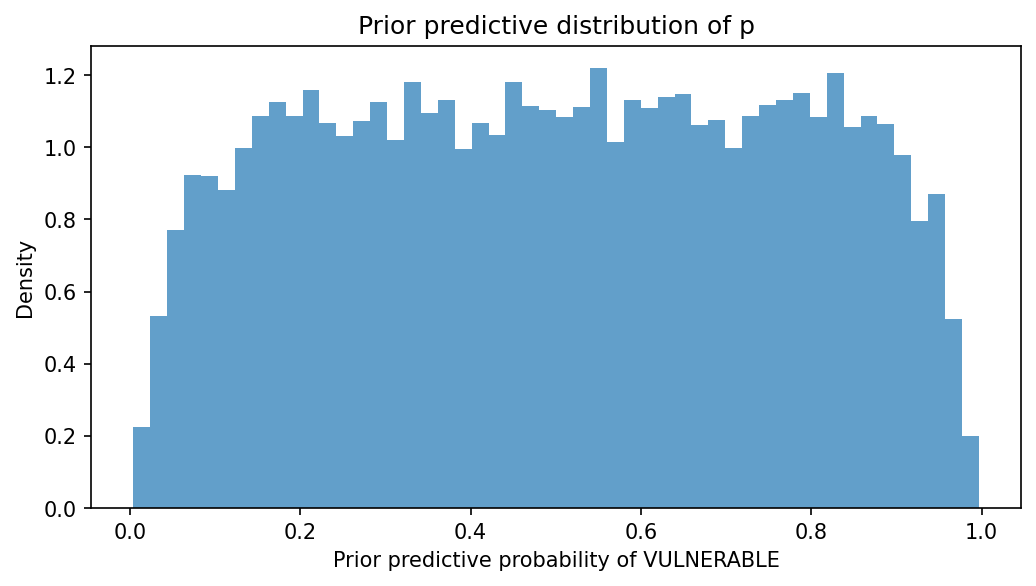

In [9]:
prior_p = prior_pred.prior["p"].values 
prior_p_flat = prior_p.flatten()

plt.figure(figsize=(8, 4))
plt.hist(prior_p_flat, bins=50, density=True, alpha=0.7)
plt.xlabel("Prior predictive probability of VULNERABLE")
plt.ylabel("Density")
plt.title("Prior predictive distribution of p")
plt.show()

The figure shows the prior predictive distribution of the probability $p$ for a model predicting vulnerability. Before seeing any data, this tells us what kinds of probabilities the model thinks are plausible.

The distribution is roughly uniform across the entire range from $0$ to $1$. This means that, before seeing the data, the model treats every possible vulnerability rate as approximately equally plausible. It does not lean toward LLMs being mostly safe, mostly vulnerable, or anywhere in between.

We used $\text{Normal}(0, 1)$ priors for both the intercept and the LLM effects. This is a weakly informative prior, and this is the behaviour we want from a weakly informative prior. The model is flexible enough to capture strong differences between LLMs if they exist in the data, but it does not assume any particular outcome in advance, and that is why we decided to use it.

Overall, the prior predictive check suggests that the priors are reasonable. Broad, symmetric, approximately uniform on the probability scale, and free of strong assumptions about how vulnerable LLM-generated code tends to be.

### Posterior predictive check

In [10]:
with model_index:
    post_pred = pm.sample_posterior_predictive(
        trace_model_index, random_seed=42
    )

Sampling: [y]


Output()

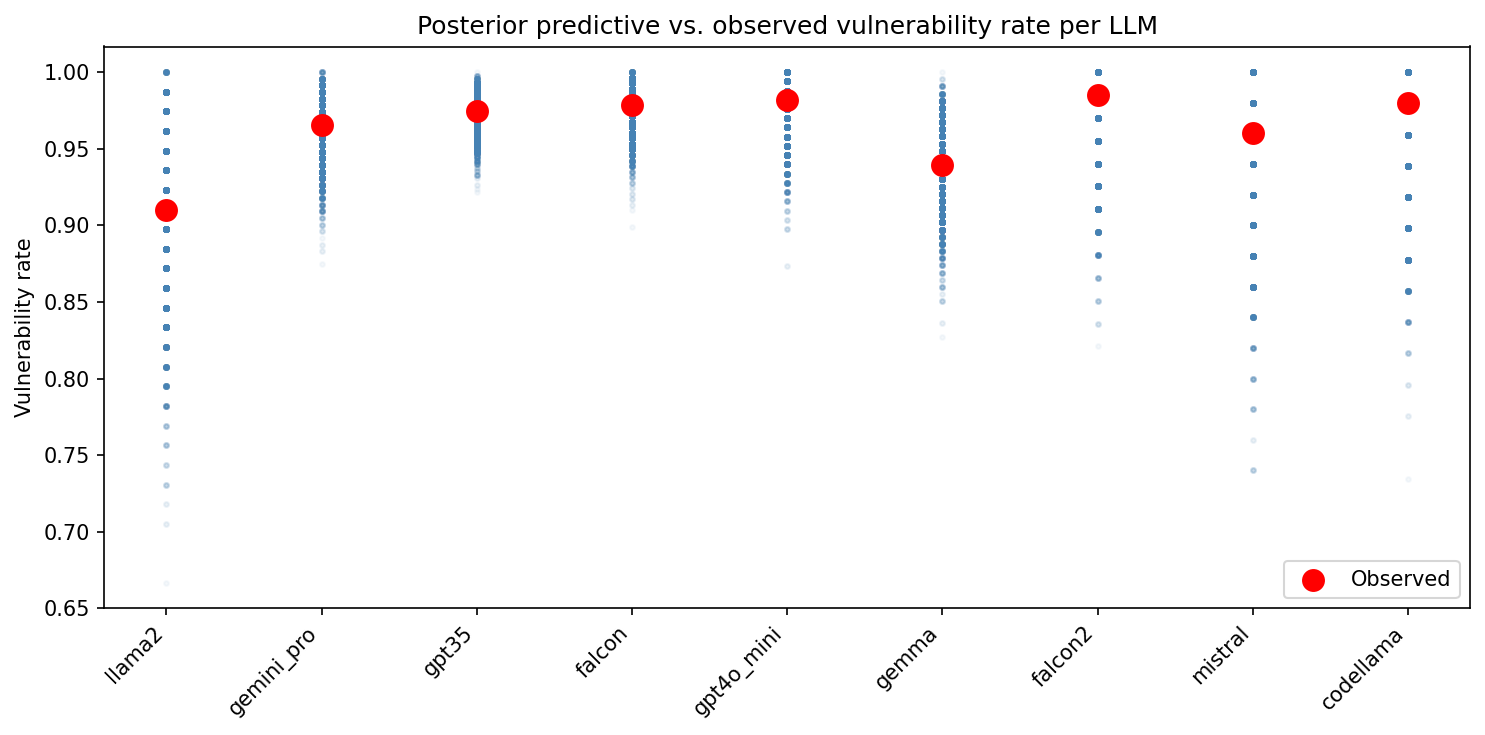

In [11]:
# posterior predictive samples
y_pred = post_pred.posterior_predictive["y"].values # simulated outcomes of model
y_pred_flat = y_pred.reshape(-1, y_pred.shape[-1]) # reshape

fig, ax = plt.subplots(figsize=(10, 5)) # create plot canvas

for j, llm in enumerate(llm_categories): # loop over llms
    mask = (llm_idx == j) # selects rows for current llm
            # e.g. (T, T, F, F, T)
    # observed rate 
    observed_rate = df.loc[mask, "outcome"].mean()
    
    # predicted rate per posterior sample for this LLM
    predicted_rates = y_pred_flat[:, mask].mean(axis=1)
    
    ax.scatter(
        np.full(len(predicted_rates), j), # x: creates an array with j repeated as many times as pred_rates, for x vals
        predicted_rates, # y
        alpha=0.05, # transparency
        color="steelblue", 
        s=5) # scatter size
    ax.scatter(
        j, # x
        observed_rate, # y
        color="red", 
        s=100, # scatter size
        zorder=5, # 
        label="Observed" if j == 0 else "") # to avoid legend spam

ax.set_xticks(range(len(llm_categories))) # labels llms
ax.set_xticklabels(llm_categories, rotation=45, ha="right")
ax.set_ylabel("Vulnerability rate")
ax.set_title("Posterior predictive vs. observed vulnerability rate per LLM")
ax.legend()
plt.tight_layout()
plt.show()

The figure shows the posterior predictive check for the index-coded model. 

For each LLM, the blue points represent the distribution of vulnerability 
rates predicted by the model across posterior draws. Denser regions 
indicate values the model considers more probable. The red point shows 
the observed vulnerability rate in the dataset.

For every LLM, the  observed rate falls within the dense central region 
of the predicted distribution, indicating that the model accurately reproduces the 
per-LLM vulnerability rates observed in the data. Some LLMs (like `falcon`, `gpt35`, `mistral`,...) 
have tight clouds, while others (like `llama2`, `gemma`, `gpt4o_mini`,...) have wider clouds. This 
reflects sample size, so LLMs with more programs in the dataset have less posterior uncertainty about 
their rate, so the cloud is narrower. 

This confirms that  the model is a structurally adequate representation of the data, and 
that the hypothesis test on `llama2` reported above is based on a model 
that fits the observed outcomes well.

## (2) Reference coded model

For each program $i = 1, \ldots, N$, the outcome is binary:

$$
Y_i =
\begin{cases}
1 & \text{if VULNERABLE} \\
0 & \text{if NON-VULNERABLE}
\end{cases}
$$

Let `llama2` be the reference category, and let $K$ be the number of 
remaining LLMs. For each program $i$ and each non-reference LLM 
$k = 1, \ldots, K$, define the dummy indicator:

$$
x_{ik} =
\begin{cases}
1 & \text{if program } i \text{ was generated by LLM } k \\
0 & \text{otherwise}
\end{cases}
$$

When all $x_{ik} = 0$, the program was generated by `llama2`. We model the 
probability that program $i$ is vulnerable, $p_i$, as:

$$
\begin{aligned}
Y_i &\sim \text{Bernoulli}(p_i) \\
\text{logit}(p_i) &= \alpha + \sum_{k=1}^{K} \beta_k \, x_{ik} \\
\alpha &\sim \mathcal{N}(0, 1) \\
\beta_k &\sim \mathcal{N}(0, 1)
\end{aligned}
$$

In this parameterization $\alpha$ is the log-odds of vulnerability for 
programs generated by `llama2` (the reference), and each $\beta_k$ is the 
log-odds difference between LLM $k$ and `llama2`. A positive $\beta_k$ 
therefore indicates that LLM $k$ is more likely to produce vulnerable 
programs than `llama2`, which makes the hypothesis test direct: under the 
research hypothesis, we expect every $\beta_k$ to be positive.

The dataset was again prepared by filtering programs with known vulnerability status and converting the target variable into a binary outcome (`1 = vulnerable`, `0 = non-vulnerable`). The LLM `llama2` was then set as the reference category by manually defining the ordering of categorical levels. A dummy-encoded design matrix was constructed for the remaining LLMs, allowing the Bayesian logistic regression model to estimate each model’s effect relative to `llama2`.

In [12]:
df = pd.read_csv("dataset.csv") # load data
df = df[df["category"].isin(["VULNERABLE", "NON-VULNERABLE"])].copy() # keep only rows where vulnerability status is known
df["outcome"] = (df["category"] == "VULNERABLE").astype(int) # converts VULNERABLE -> 1, NON-VULNERABLE -> 0

# set llama2 as reference level
llms = df["llm_name"].unique().tolist() # get all unique LLM names as list
llms.remove("llama2") # remove llama2 from the list
llm_categories = ["llama2"] + sorted(llms)

# convert col to categorical with fixed ordering
df["llm_name"] = pd.Categorical(df["llm_name"], categories=llm_categories)

# recompute llm_idx using the new category ordering
llm_idx = df["llm_name"].cat.codes.to_numpy()

# build design matrix (drop_first=True now drops llama2)
X = pd.get_dummies(df["llm_name"], drop_first=True).astype(float)
predictor_names = X.columns.tolist() # save column names

X_values = X.values
y_values = df["outcome"].values

coords = {"llm": predictor_names}  # names for beta

In [13]:
with pm.Model(coords=coords) as model_reference:
    # log-odds of vulnerability for llama2
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    # one coefficient per LLM
    beta = pm.Normal("beta", mu=0, sigma=1, dims="llm")

    logit_p = alpha + pm.math.dot(X_values, beta)

    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    y_obs = pm.Bernoulli("y", p=p, observed=y_values)

    trace_model_reference = pm.sample(
        draws=2000, 
        tune=1000,
        random_seed=42, 
        chains=4,
        progressbar=True,
        return_inferencedata=True
        )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


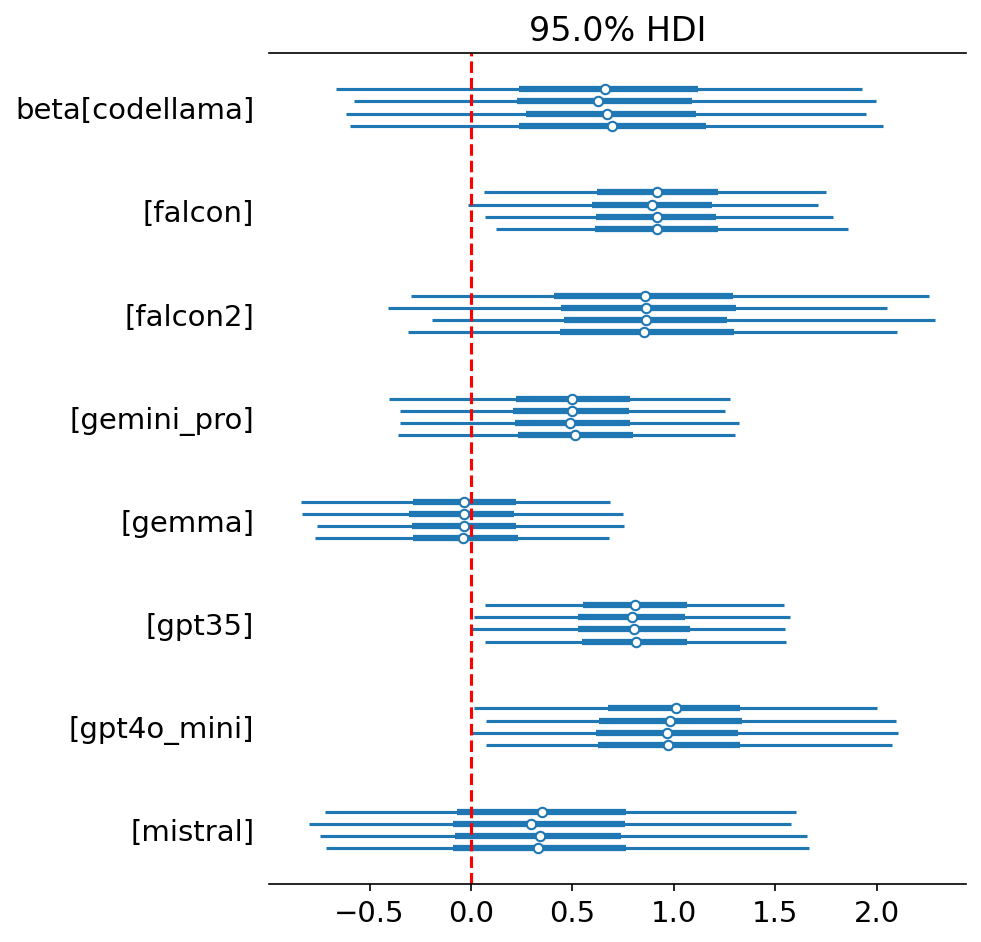

In [14]:
axes = az.plot_forest(trace_model_reference, var_names=["beta"], hdi_prob=.95)

for ax in np.ravel(axes):
    ax.axvline(0, color="red", linestyle="--")

### Hypothesis discussion

The plot above shows the posterior distributions of the coefficients $\beta_k$ 
from the reference-coded model, in which `llama2` is the reference 
category. Each $\beta_k$ represents the log-odds difference 
between LLM $k$ and `llama2`, so positive values indicate LLMs that are 
more likely than `llama2` to produce vulnerable programs. Under the  hypothesis, we expect every $\beta_k$ to be clearly positive, 
that is, every 95% HDI should lie entirely above zero.

This is observed for three LLMs: `falcon`, `gpt35`, and 
`gpt4o_mini` all have HDIs that exclude zero. Three further 
LLMs, `codellama`, `falcon2`, and `gemini_pro`, have HDIs that only 
slightly cross zero, with the great majority of their posterior mass on 
the positive side. These are consistent with the hypothesis but provide 
slightly weaker evidence individually. `mistral` has its HDI mostly above 
zero but with substantial probability near and below zero (median $\approx$ 0.7), 
making the comparison a bit inconclusive. Finally, `gemma` is 
centered very close to zero with an HDI roughly symmetric around it, 
indicating no clear difference from `llama2`.

The reference-coded results tell the same conclusion as the 
index-coded model and the pairwise probabilities: `llama2` is clearly 
safer than most of the LLMs in the dataset, but the hypothesis in its 
strict form, that `llama2` dominates *every* other LLM, is not fully 
supported, because `gemma` cannot be confidently distinguished from 
`llama2` and the evidence against `mistral` is only moderate. 

### Trace convergence

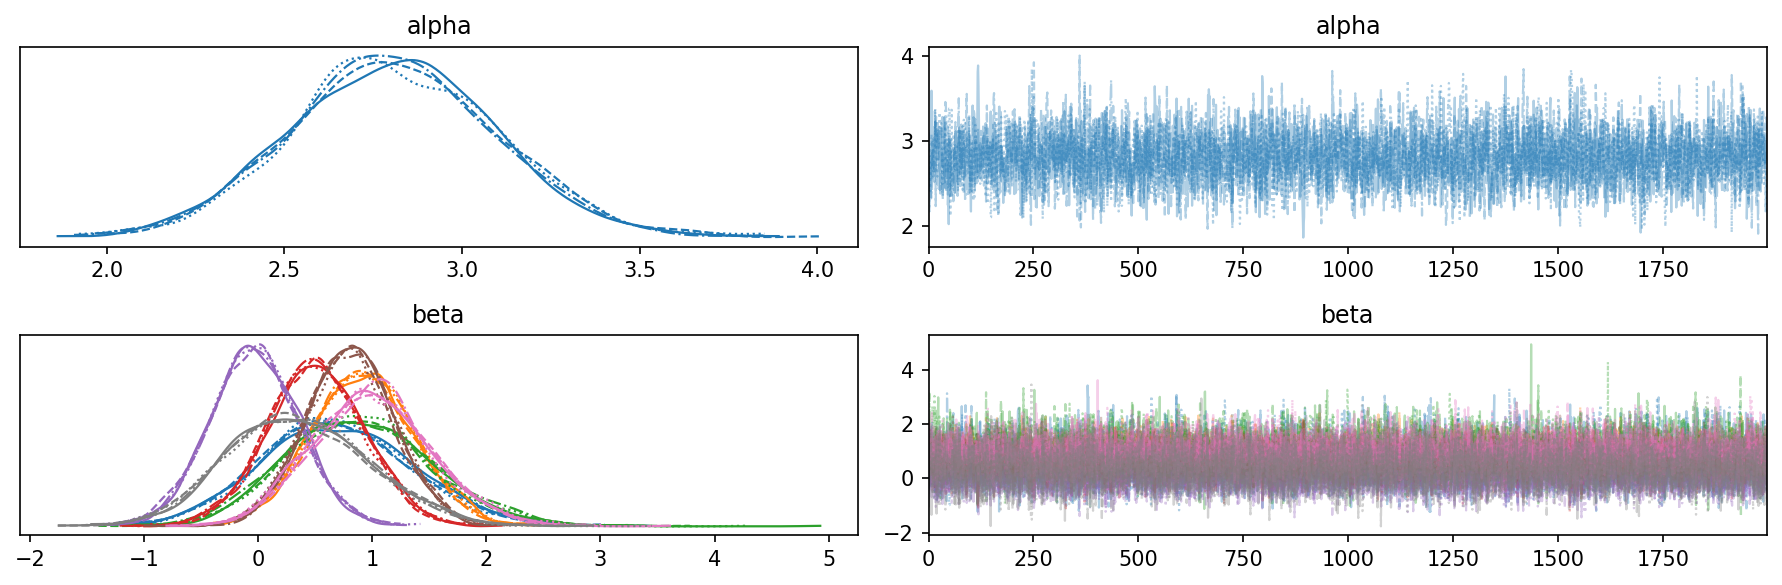

In [15]:
az.plot_trace(trace_model_reference, var_names=["alpha", "beta"])
plt.tight_layout()
plt.show()


Just as in the previous model, these plots suggest that the sampler has converged and is behaving as expected. 

The chains overlap almost perfectly here for both parameters, which suggets they are converging to the same distribution. 

The trace plots fluctuate around a stable mean with no trends or drifts without getting stuck.

In [16]:
summary = az.summary(
    trace_model_reference,
    var_names=["alpha", "beta"],
    hdi_prob=0.95,
    round_to=4,
)
print(summary)

                    mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
alpha             2.8106  0.2913    2.2284     3.3630     0.0051   0.0036   
beta[codellama]   0.6933  0.6638   -0.6764     1.9241     0.0072   0.0064   
beta[falcon]      0.9149  0.4426    0.0756     1.8106     0.0061   0.0043   
beta[falcon2]     0.8846  0.6388   -0.3416     2.1503     0.0067   0.0056   
beta[gemini_pro]  0.5038  0.4239   -0.3506     1.3138     0.0058   0.0042   
beta[gemma]      -0.0359  0.3889   -0.7955     0.7382     0.0058   0.0041   
beta[gpt35]       0.8032  0.3914    0.0677     1.5944     0.0057   0.0040   
beta[gpt4o_mini]  0.9956  0.5234    0.0216     2.0639     0.0062   0.0047   
beta[mistral]     0.3517  0.6177   -0.7214     1.6572     0.0068   0.0064   

                   ess_bulk   ess_tail   r_hat  
alpha             3256.2889  4403.2101  1.0005  
beta[codellama]   8778.7289  5163.5140  1.0009  
beta[falcon]      5296.7819  5502.6390  1.0001  
beta[falcon2]     9371.4461  5596

Again, $\hat{R}$ values are around $1$, which is a good sign, further confirming the convergence.

### Prior predictive check

In [17]:
with model_reference:
    prior_pred = pm.sample_prior_predictive(samples=2000, random_seed=42)

Sampling: [alpha, beta, y]


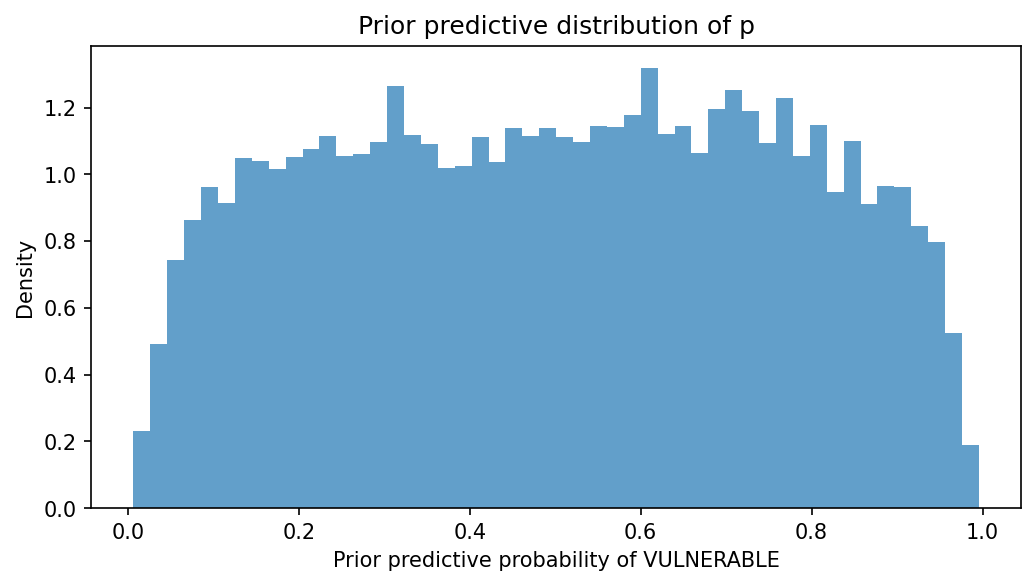

In [18]:
prior_p = prior_pred.prior["p"].values 
prior_p_flat = prior_p.flatten()

plt.figure(figsize=(8, 4))
plt.hist(prior_p_flat, bins=50, density=True, alpha=0.7)
plt.xlabel("Prior predictive probability of VULNERABLE")
plt.ylabel("Density")
plt.title("Prior predictive distribution of p")
plt.show()

Again, the prior predictive check is roughly uniform across the full range from $0$ to $1$, which means the priors don't strongly favor any outcome before seeing any data.

So overall, the priors behave as expected and can be considered weakly informative and appropriate for this analysis.

### Posterior predictive check

In [19]:
with model_reference:
    post_pred = pm.sample_posterior_predictive(
        trace_model_reference, random_seed=42
    )

Sampling: [y]


Output()

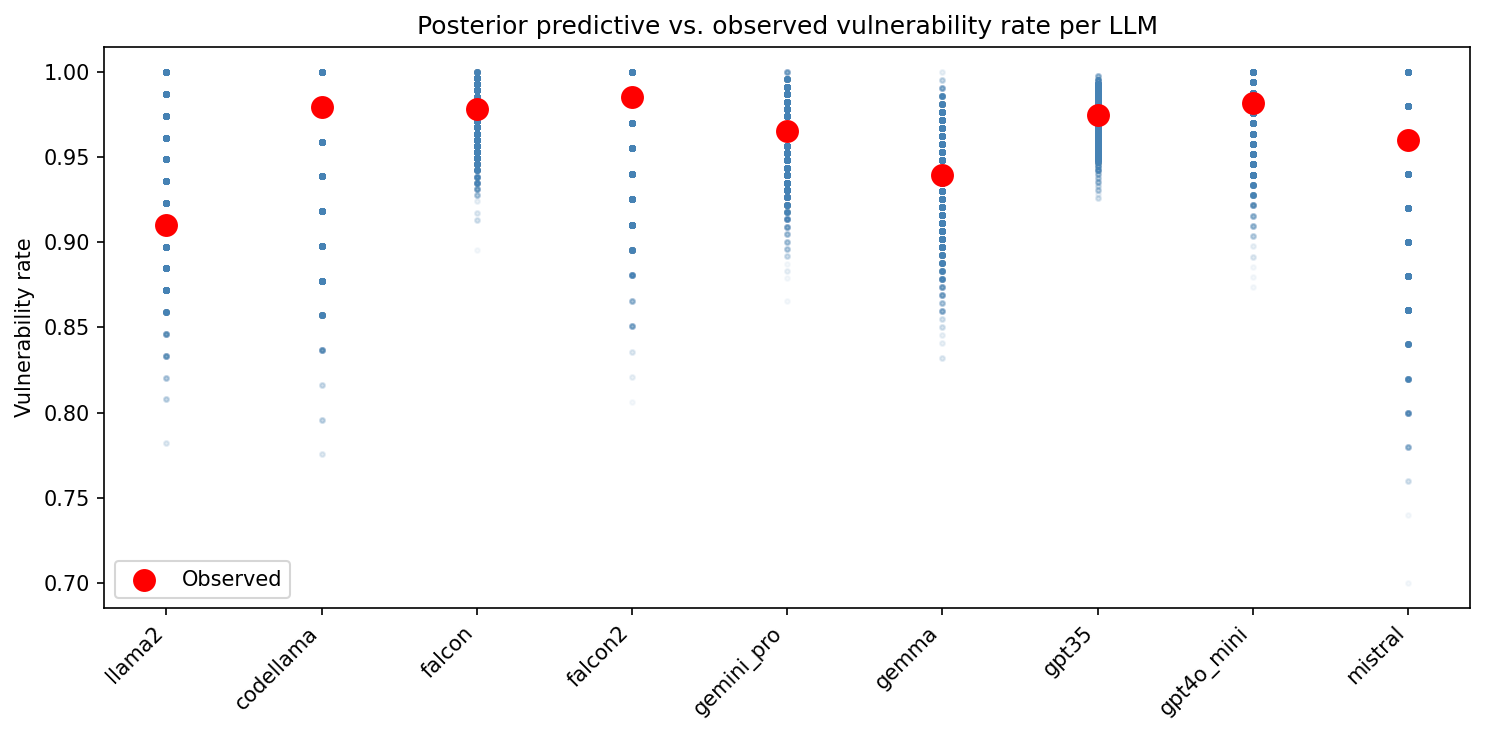

In [20]:
# posterior predictive samples
y_pred = post_pred.posterior_predictive["y"].values # simulated outcomes of model
y_pred_flat = y_pred.reshape(-1, y_pred.shape[-1]) # reshape

fig, ax = plt.subplots(figsize=(10, 5)) # create plot canvas

for j, llm in enumerate(llm_categories): # loop over llms
    mask = (llm_idx == j) # selects rows for current llm
            # e.g. (T, T, F, F, T)
    # observed rate 
    observed_rate = df.loc[mask, "outcome"].mean()
    
    # predicted rate per posterior sample for this LLM
    predicted_rates = y_pred_flat[:, mask].mean(axis=1)
    
    ax.scatter(
        np.full(len(predicted_rates), j), # x: creates an array with j repeated as many times as pred_rates, for x vals
        predicted_rates, # y
        alpha=0.05, # transparency
        color="steelblue", 
        s=5) # scatter size
    ax.scatter(
        j, # x
        observed_rate, # y
        color="red", 
        s=100, # scatter size
        zorder=5, # 
        label="Observed" if j == 0 else "") # to avoid legend spam

ax.set_xticks(range(len(llm_categories))) # labels llms
ax.set_xticklabels(llm_categories, rotation=45, ha="right")
ax.set_ylabel("Vulnerability rate")
ax.set_title("Posterior predictive vs. observed vulnerability rate per LLM")
ax.legend()
plt.tight_layout()
plt.show()

The figure shows the posterior predictive check for the reference-coded model. 

Just as before, for each LLM, the blue points represent the distribution of vulnerability 
rates predicted by the model across posterior draws — denser regions 
indicate values the model considers more probable. The red point shows 
the observed vulnerability rate in the dataset.

For every LLM, the  observed rate falls within the dense central region 
of the predicted distribution, indicating that the model accurately reproduces the 
per-LLM vulnerability rates observed in the data. 

This confirms that  the model is a structurally adequate representation of the data, and 
that the hypothesis test on llama2 reported above is based on a model 
that fits the observed outcomes well.

## Overall conclusion

Both the index-coded and reference-coded models point to the same picture, which is good since they are equivalent reparameterisations of the same logistic regression. For both views, `llama2` consistently shows as the LLM with the lowest probability of producing vulnerable programs.

We can say the hypothesis is **partially supported**. `llama2` is clearly safer than most of the LLMs we looked at, but we can't say with confidence that it's safer than every single one.

# Hypothesis 2

The second hypothesis is: larger values of cyclomatic complexity (CC) are
associated with a larger number of lines of code (LOC), and this relationship
holds for all LLMs in the dataset.

Cyclomatic complexity measures how many independent decision paths exist in a
program. Intuitively, a longer program has more room for `if`, `while`, and
`switch` statements, so we would expect CC to grow with LOC. But does this
hold for every LLM, or only some of them?

To answer this, we build a hierarchical linear regression model where each
LLM gets its own intercept and slope. The slope β is the key parameter: if β
is clearly positive for an LLM, then more lines of code are associated with
higher cyclomatic complexity for that LLM. H2 is supported only if this holds
for every LLM.

We fit two versions of the model:
- **1. Normal likelihood** — the standard choice, simple and stable.
- **2. TruncatedNormal likelihood** — theoretically more correct, since CC ≥ 1
  always, meaning log(CC) ≥ 0. We use this as a robustness check.

## Data loading and cleaning

We load the dataset and remove rows where the program did not run correctly
(parsing errors or verification timeouts). These rows do not have reliable
LOC or CC values, so we exclude them. We keep only VULNERABLE and
NON-VULNERABLE rows.

In [21]:
df_h2 = pd.read_csv('dataset.csv')

# Filter to only include VULNERABLE and NON-VULNERABLE categories
df_h2 = df_h2[df_h2['category'].isin(['VULNERABLE', 'NON-VULNERABLE'])].copy()
# Reset index
df_h2 = df_h2.reset_index(drop=True)


## Log transformation and standardization

Both LOC and CC are right-skewed. Taking the logarithm compresses the scale
and makes the relationship more linear. After the log transform, we standardize
log(LOC) by subtracting the mean and dividing by the standard deviation. This
puts the predictor on a scale centered at zero, which helps PyMC sample more
efficiently.

The transformations applied are:

$$y_i = \log(\text{CC}_i)$$

$$z_i = \frac{\log(\text{LOC}_i) - \mu_{\log(\text{LOC})}}{\sigma_{\log(\text{LOC})}}$$

where $y_i$ is the log-transformed CC and $z_i$ is the standardized log-transformed LOC.

After standardization, `log_loc_std` has mean 0 and standard deviation 1.
We only standardize the predictor (LOC), not the outcome (CC).

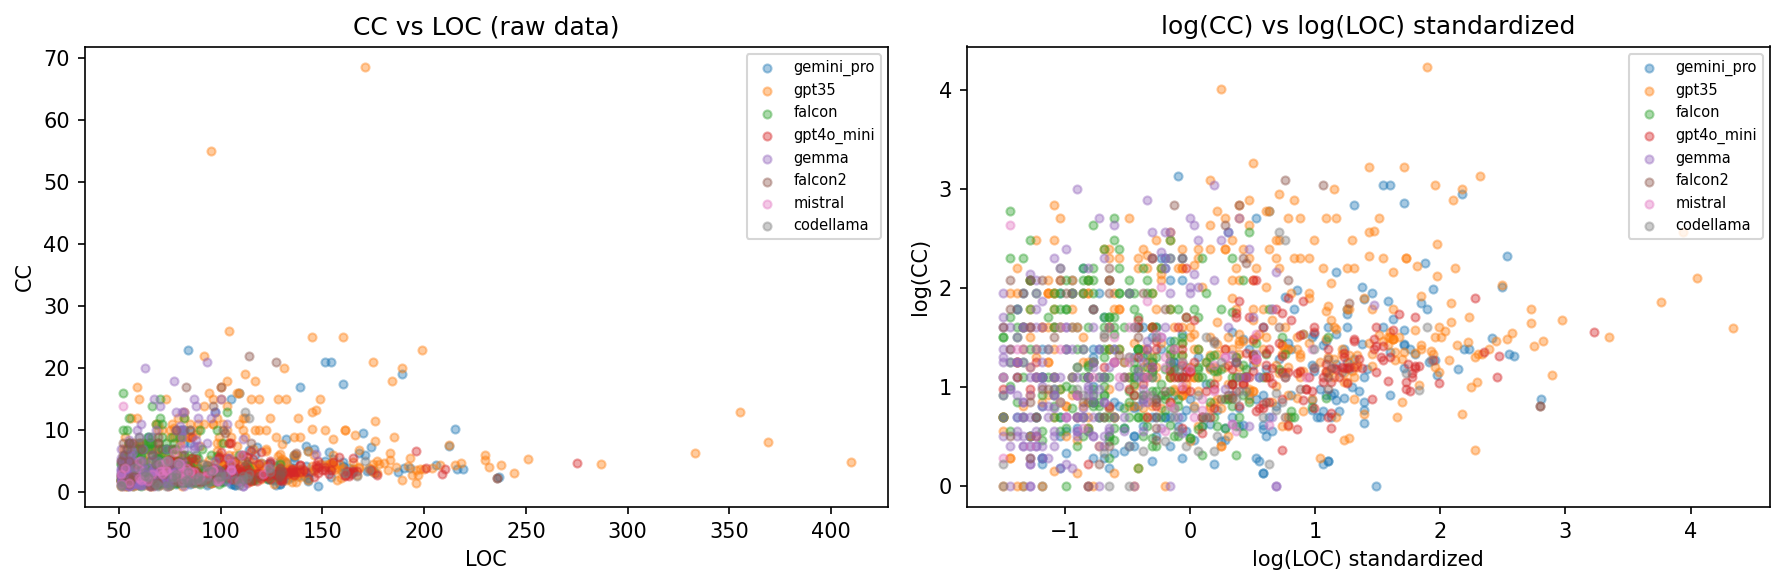

In [22]:
# Log transformation
df_h2['log_loc'] = np.log(df_h2['num_lines'])
df_h2['log_cc']  = np.log(df_h2['cyclomatic_complexity'])

# Standardize log(LOC)
loc_mean = df_h2['log_loc'].mean()
loc_std  = df_h2['log_loc'].std()
df_h2['log_loc_std'] = (df_h2['log_loc'] - loc_mean) / loc_std

# Side by side scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before transformation
# get colors 
colors = plt.cm.tab10.colors[:len(llms)]
for llm, color in zip(llms, colors):
    mask = df_h2['llm_name'] == llm
    axes[0].scatter(df_h2.loc[mask, 'num_lines'],
                    df_h2.loc[mask, 'cyclomatic_complexity'],
                    label=llm, alpha=0.4, s=15, color=color)
axes[0].set_title('CC vs LOC (raw data)')
axes[0].set_xlabel('LOC')
axes[0].set_ylabel('CC')
axes[0].legend(fontsize=7)

# After transformation
for llm, color in zip(llms, colors):
    mask = df_h2['llm_name'] == llm
    axes[1].scatter(df_h2.loc[mask, 'log_loc_std'],
                    df_h2.loc[mask, 'log_cc'],
                    label=llm, alpha=0.4, s=15, color=color)
axes[1].set_title('log(CC) vs log(LOC) standardized')
axes[1].set_xlabel('log(LOC) standardized')
axes[1].set_ylabel('log(CC)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Preparing data for PyMC

We encode each LLM name as an integer index so we can use it to index into the per-LLM parameters inside
the model because PyMC works with numeric, not strings. 

In [23]:
# LLM Names
llm_names = df_h2['llm_name'].unique().tolist()

# Encode each LLM as an integer
llm_to_idx = {name: i for i, name in enumerate(llm_names)}
llm_idx = df_h2['llm_name'].map(llm_to_idx).values

# Number of LLMs
n_llms = len(llm_names)

# Extract as numpy arrays
log_loc_std_vals = df_h2['log_loc_std'].values
log_cc_vals      = df_h2['log_cc'].values

print(f"Number of LLMs: {n_llms}")
print(f"LLM index mapping: {llm_to_idx}")

Number of LLMs: 9
LLM index mapping: {'llama2': 0, 'gemini_pro': 1, 'gpt35': 2, 'falcon': 3, 'gpt4o_mini': 4, 'gemma': 5, 'falcon2': 6, 'mistral': 7, 'codellama': 8}


## Model

We use a **hierarchical linear regression** model. Each LLM gets its own
intercept α and slope β, both drawn from a shared population distribution.
LLMs with few programs borrow strength from the group; LLMs with many programs
rely more on their own data.

The model is:

$$
\log(\text{CC})_i \sim \mathcal{N}(\mu_i, \sigma)
$$
$$
\mu_i = \alpha_{\text{LLM}[i]} + \beta_{\text{LLM}[i]} \cdot z_i
$$
$$
\alpha_j \sim \mathcal{N}(\mu_\alpha, \sigma_\alpha), \quad \beta_j \sim \mathcal{N}(\mu_\beta, \sigma_\beta)
$$

where $z_i$ is the standardized log(LOC), stored in the variable `log_loc_std`.


The slope β is the key parameter for H2. If β > 0 for all LLMs, H2 is supported.

## (1) Normal likelihood model

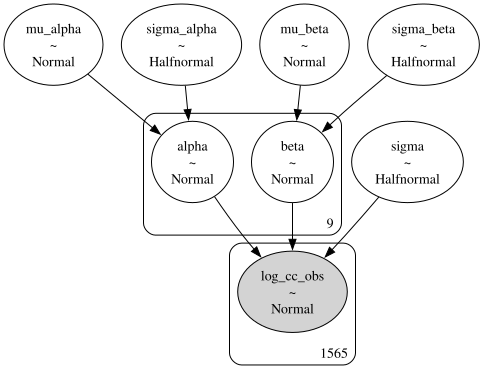

In [ ]:
with pm.Model() as model_h2_normal:

    # Hyperpriors
    mu_alpha    = pm.Normal('mu_alpha', mu=0, sigma=1)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=1)

    mu_beta     = pm.Normal('mu_beta', mu=0, sigma=1)
    sigma_beta  = pm.HalfNormal('sigma_beta', sigma=1)

    # Per-LLM intercept — baseline log(CC) for each LLM
    alpha = pm.Normal('alpha', mu=mu_alpha, sigma=sigma_alpha, shape=n_llms)

    # Per-LLM slope — main parameter for H2
    beta  = pm.Normal('beta', mu=mu_beta, sigma=sigma_beta, shape=n_llms)

    # Residual noise
    sigma = pm.HalfNormal('sigma', sigma=1)

    # Expected log(CC) for each program
    mu = alpha[llm_idx] + beta[llm_idx] * log_loc_std_vals

    # Likelihood — observed log(CC) values
    log_cc_obs = pm.Normal('log_cc_obs', mu=mu, sigma=sigma, observed=log_cc_vals)

g = pm.model_to_graphviz(model_h2_normal)
g.graph_attr['size'] = '6,4'
g

## (2) TruncatedNormal likelihood model

Since every program has CC ≥ 1, we know that log(CC) ≥ 0 always. The Normal
likelihood ignores this and can predict negative log(CC) values, which are
impossible in practice. The TruncatedNormal likelihood fixes this by setting
a hard lower bound at zero.

We use this model as a **robustness check**. If both models lead to the same
conclusion for H2, we can be more confident in the result.

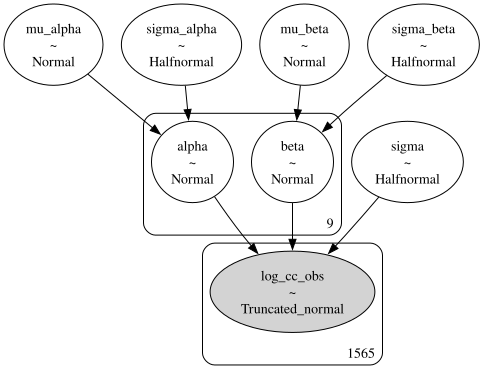

In [ ]:
with pm.Model() as model_h2_truncated:

    # Hyperpriors
    mu_alpha    = pm.Normal('mu_alpha', mu=0, sigma=1)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=1)

    mu_beta     = pm.Normal('mu_beta', mu=0, sigma=1)
    sigma_beta  = pm.HalfNormal('sigma_beta', sigma=1)

    # Per-LLM intercept — baseline log(CC) for each LLM
    alpha = pm.Normal('alpha', mu=mu_alpha, sigma=sigma_alpha, shape=n_llms)

    # Per-LLM slope — main parameter for H2
    beta  = pm.Normal('beta', mu=mu_beta, sigma=sigma_beta, shape=n_llms)

    # Residual noise
    sigma = pm.HalfNormal('sigma', sigma=1)

    # Expected log(CC) for each program
    mu = alpha[llm_idx] + beta[llm_idx] * log_loc_std_vals

    # Likelihood — TruncatedNormal enforces log(CC) >= 0
    log_cc_obs = pm.TruncatedNormal('log_cc_obs', mu=mu, sigma=sigma, lower=0, observed=log_cc_vals)

g = pm.model_to_graphviz(model_h2_truncated)
g.graph_attr['size'] = '6,4'
g

## Choice of Priors

The priors were chosen to be weakly informative.     
- We used `Normal(0, 1)` for the hyperparameters because after log-transforming and standardizing LOC, 
the data is already on a small scale, so this prior covers a reasonable range 
without being too restrictive. 
- `HalfNormal(1)` was used for the scale 
parameters simply because they must be positive.

## Prior predictive check

Before fitting the models, we check whether our priors generate reasonable
values of log(CC). We want the prior predictive distribution to cover the
actual range of the data, without being too wide or too narrow.

The key difference between the two models is visible here: TruncatedNormal
produces no values below zero, while Normal does. Values below zero correspond
to CC < 1, which is impossible in practice.

Sampling: [alpha, beta, log_cc_obs, mu_alpha, mu_beta, sigma, sigma_alpha, sigma_beta]
Sampling: [alpha, beta, log_cc_obs, mu_alpha, mu_beta, sigma, sigma_alpha, sigma_beta]


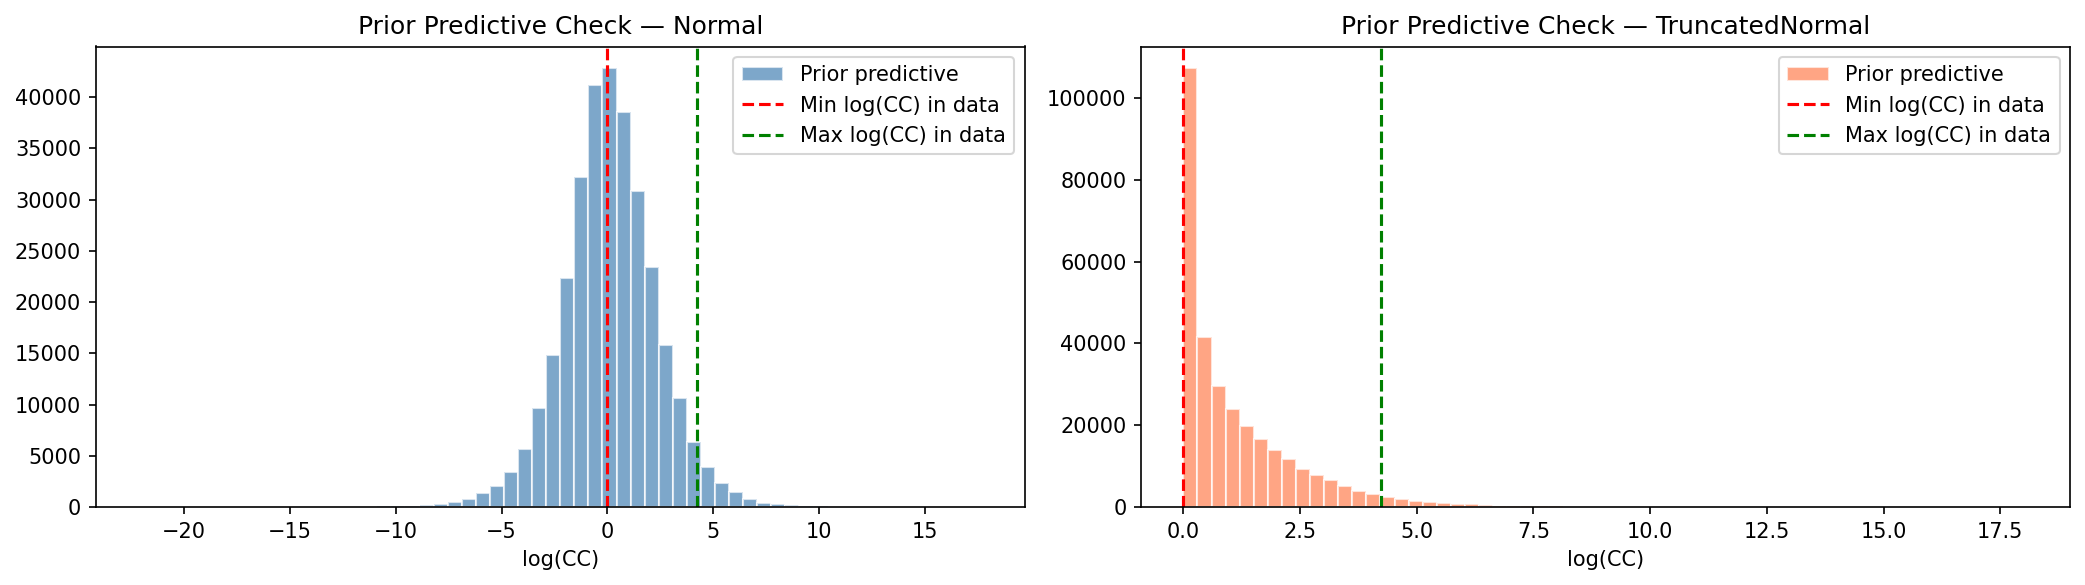

In [26]:
# Sample prior predictive
with model_h2_normal:
    prior_pred_normal = pm.sample_prior_predictive(samples=200, random_seed=42)

with model_h2_truncated:
    prior_pred_truncated = pm.sample_prior_predictive(samples=200, random_seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Normal model
axes[0].hist(
    prior_pred_normal.prior_predictive['log_cc_obs'].values.flatten(),
    bins=60, color='steelblue', edgecolor='white', alpha=0.7, label='Prior predictive'
)
axes[0].axvline(log_cc_vals.min(), color='red', linestyle='--', label='Min log(CC) in data')
axes[0].axvline(log_cc_vals.max(), color='green', linestyle='--', label='Max log(CC) in data')
axes[0].set_xlabel('log(CC)')
axes[0].set_title('Prior Predictive Check — Normal')
axes[0].legend()

# TruncatedNormal model
axes[1].hist(
    prior_pred_truncated.prior_predictive['log_cc_obs'].values.flatten(),
    bins=60, color='coral', edgecolor='white', alpha=0.7, label='Prior predictive'
)
axes[1].axvline(log_cc_vals.min(), color='red', linestyle='--', label='Min log(CC) in data')
axes[1].axvline(log_cc_vals.max(), color='green', linestyle='--', label='Max log(CC) in data')
axes[1].set_xlabel('log(CC)')
axes[1].set_title('Prior Predictive Check — TruncatedNormal')
axes[1].legend()

plt.tight_layout()
plt.show()

## Sampling

We run MCMC sampling for both models using 4 chains and 2000 draws each.

For the **Normal model**, standard settings (tune=2000, target_accept=0.99)
were sufficient — no divergences were observed.

For the **TruncatedNormal model**, we initially ran with tune=2000 and
observed 7 divergences. Divergences occur when the sampler struggles with
regions of the posterior that have complex geometry — in this case, the hard
lower bound at zero creates a sharp boundary that the sampler has to navigate
carefully. Increasing tune to 4000 gave the sampler more warmup iterations
to adapt to this boundary, and the divergences disappeared.

Since both models use the same number of draws (2000) and chains (4), the
results are directly comparable.

In [27]:
# Normal model
with model_h2_normal:
    trace_h2_normal = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.99,
        random_seed=42
    )

# Truncated model
with model_h2_truncated:
    trace_h2_truncated = pm.sample(
        draws=2000,
        tune=4000,
        chains=4,
        target_accept=0.99,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, mu_beta, sigma_beta, alpha, beta, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, mu_beta, sigma_beta, alpha, beta, sigma]


Output()

Sampling 4 chains for 4_000 tune and 2_000 draw iterations (16_000 + 8_000 draws total) took 31 seconds.


## Sampling diagnostics

We check sampling quality using four tools:

- **R-hat** measures whether all 4 chains converged to the same distribution.
A value close to 1.0 means all chains agree on the posterior. Values above
1.01 mean the chains ended up in different parts of the parameter space,
which means the posterior estimates cannot be trusted.

- **ESS** (effective sample size) tells us how many independent samples we
effectively have. Because MCMC samples are correlated with each other, 8000
raw samples (4 chains × 2000 draws) does not equal 8000 independent samples.
A low ESS means the chains were moving slowly and the estimates are imprecise.
A high ESS means the chains mixed well and the estimates are reliable.

- **Trace plots** show the sampled values over time for each chain. Good
sampling looks like random noise — all 4 chains overlapping and bouncing
around a stable mean with no trends or jumps. Trends or drifts in the trace would indicate
the sampler got stuck or did not converge.

- **Autocorrelation plots** show how correlated each sample is with the
previous ones. High autocorrelation means the sampler was moving in small
steps and the chains were slow to explore the posterior. Low autocorrelation
means samples are nearly independent, which is what we want.

### (1) Normal likelihood model diagnostics

#### Summary

In [28]:
summary_normal = az.summary(trace_h2_normal, var_names=['alpha', 'beta', 'sigma'])
summary_normal

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],1.216,0.073,1.075,1.351,0.001,0.001,7942.0,6039.0,1.0
alpha[1],1.109,0.041,1.034,1.185,0.000,0.000,11730.0,5765.0,1.0
alpha[2],1.458,0.030,1.402,1.514,0.000,0.000,9850.0,5728.0,1.0
alpha[3],1.211,0.045,1.125,1.296,0.001,0.000,7505.0,6318.0,1.0
alpha[4],1.152,0.056,1.046,1.256,0.001,0.000,8513.0,6361.0,1.0
alpha[5],1.370,0.063,1.256,1.492,0.001,0.001,6425.0,6179.0,1.0
alpha[6],1.383,0.071,1.249,1.516,0.001,0.000,12581.0,6523.0,1.0
alpha[7],1.193,0.080,1.043,1.345,0.001,0.001,12460.0,6444.0,1.0
alpha[8],1.025,0.082,0.879,1.188,0.001,0.001,10701.0,6466.0,1.0
beta[0],0.224,0.087,0.060,0.380,0.001,0.001,6466.0,6216.0,1.0


The Normal model shows good sampling quality. All R-hat values are exactly
1.0, meaning all 4 chains converged to the same distribution. ESS values are
well above 5000 for most parameters, indicating the chains mixed efficiently
and the posterior estimates are reliable.

#### Trace plots

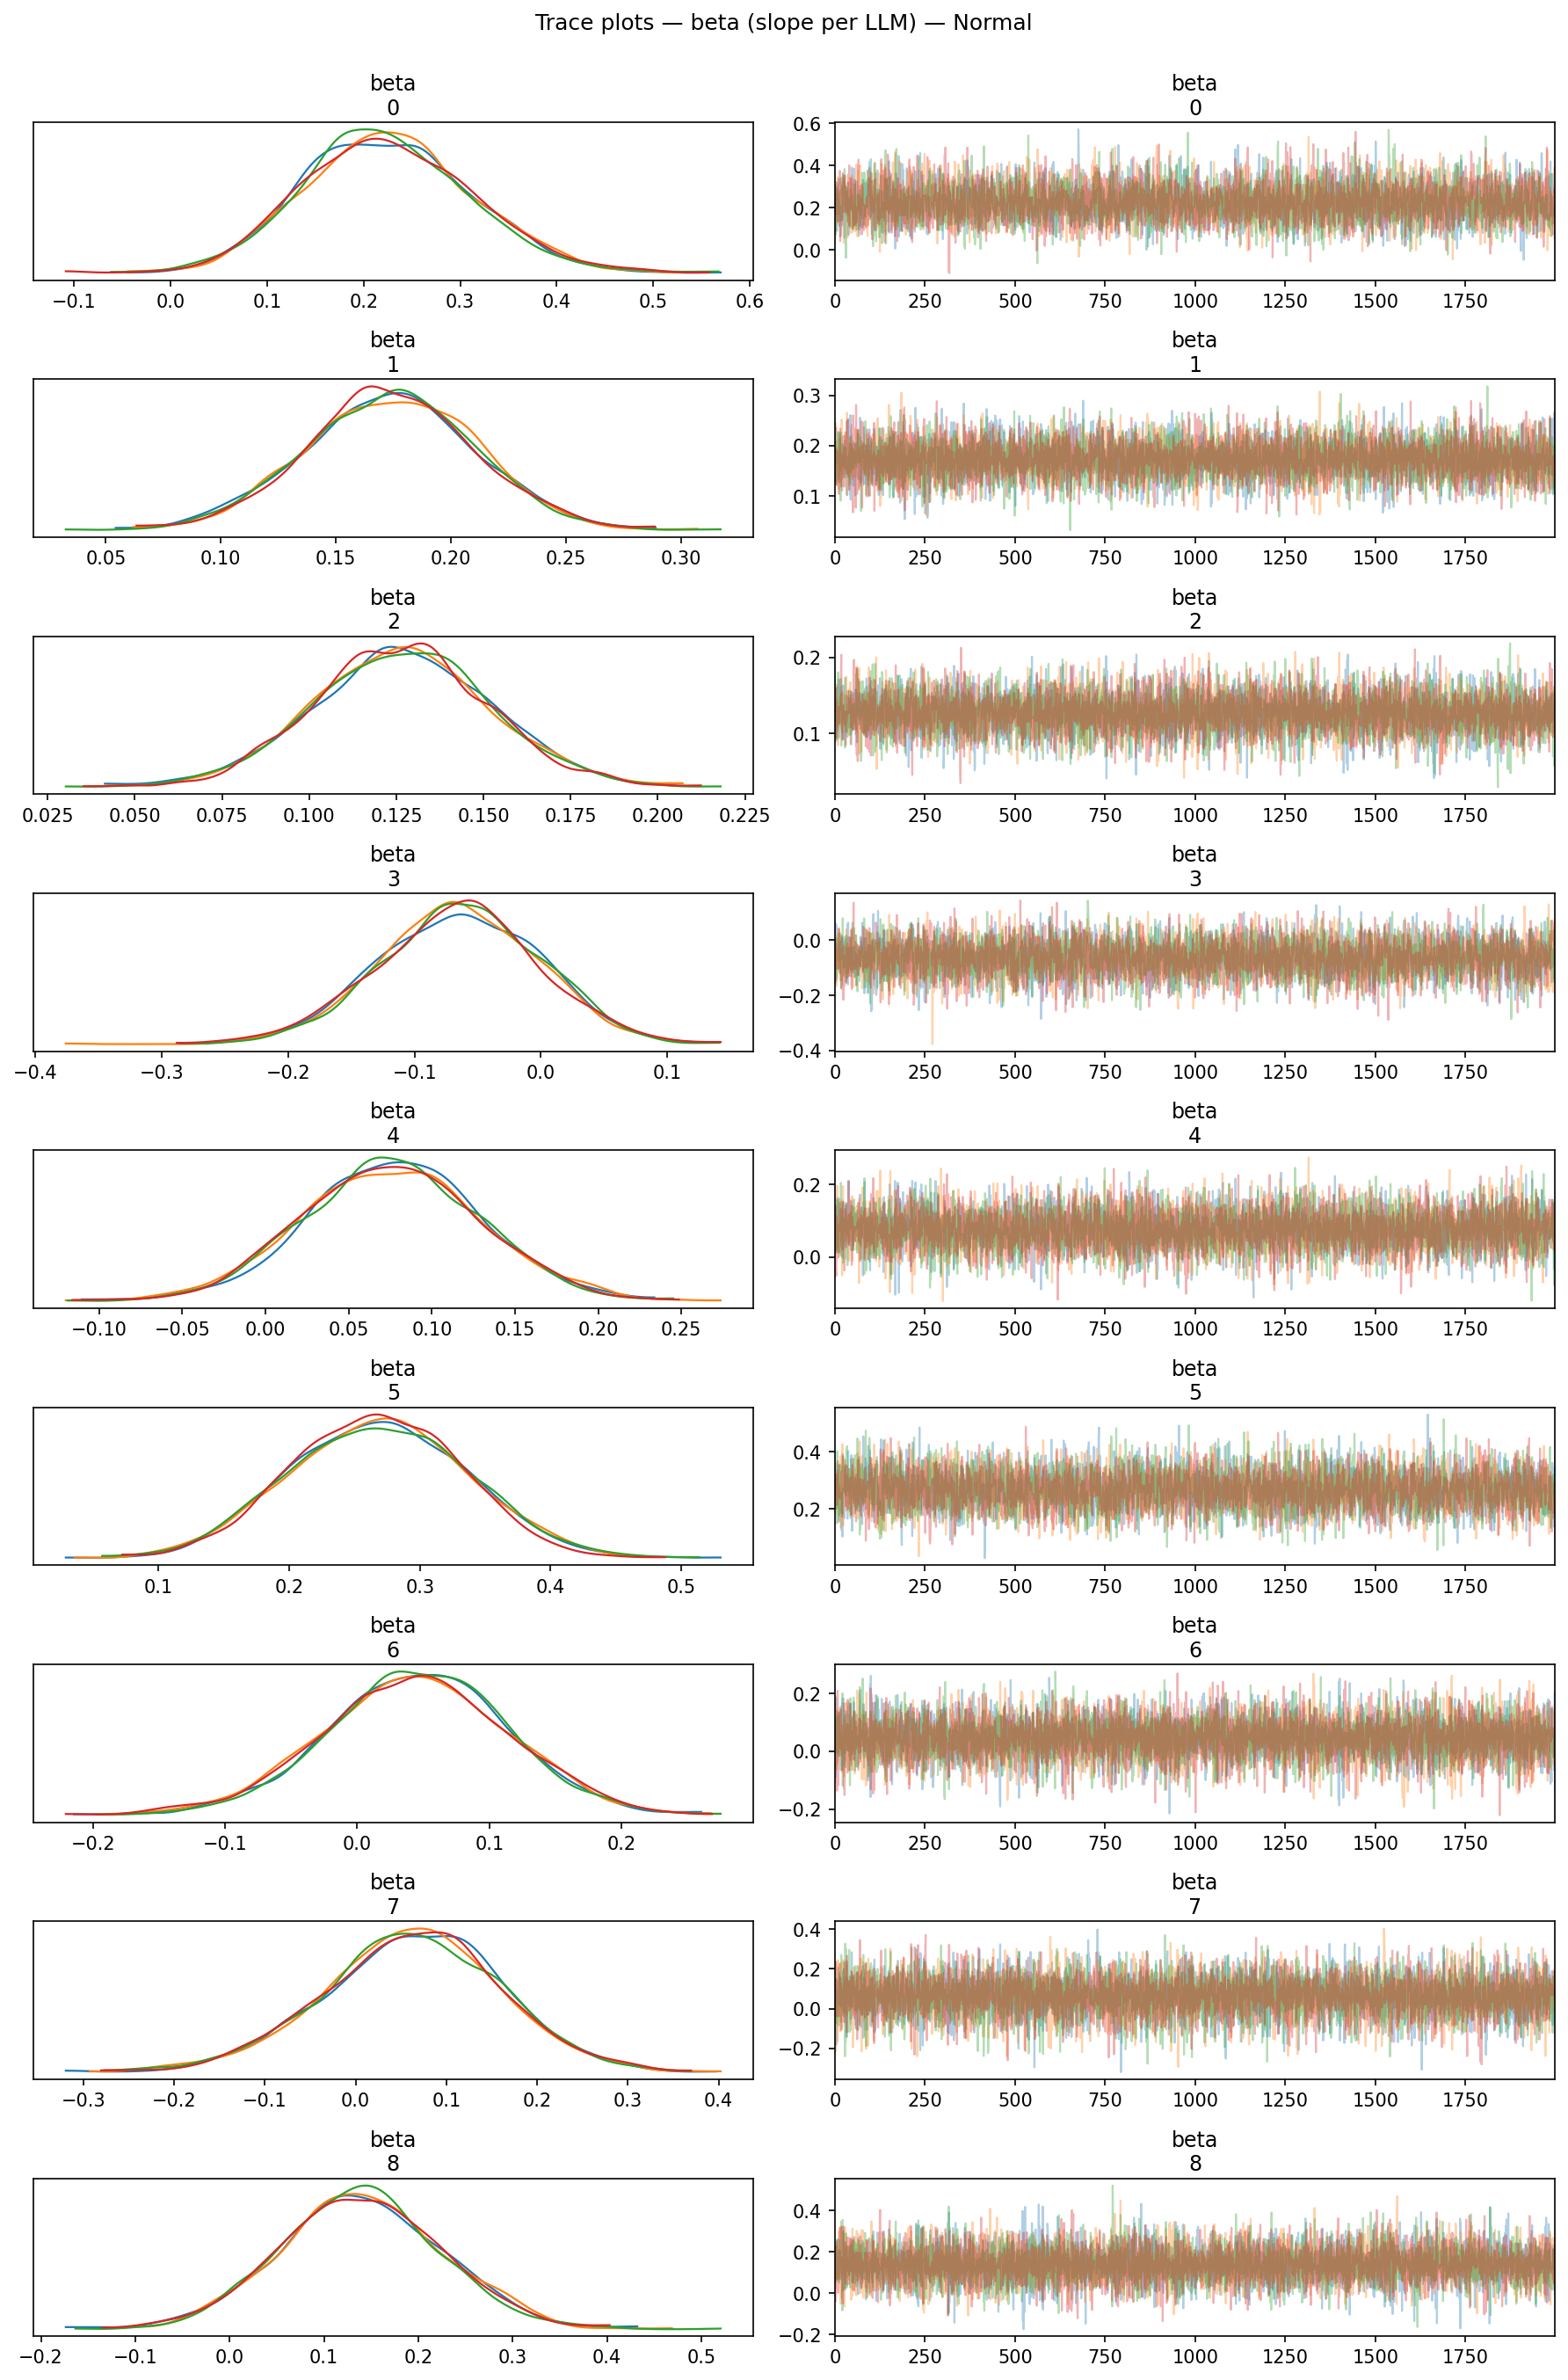

In [29]:
az.plot_trace(trace_h2_normal, var_names=['beta'], compact=False)
plt.suptitle('Trace plots — beta (slope per LLM) — Normal', y=1)
plt.tight_layout()
plt.show()

The trace plots for the Normal model look good. On the left, all 4 chains
overlap well for every beta, meaning they all converged to the same posterior.
On the right, the traces show random noise with no trends or jumps. This confirms the sampling was stable and
reliable.

#### Autocorrelation plots

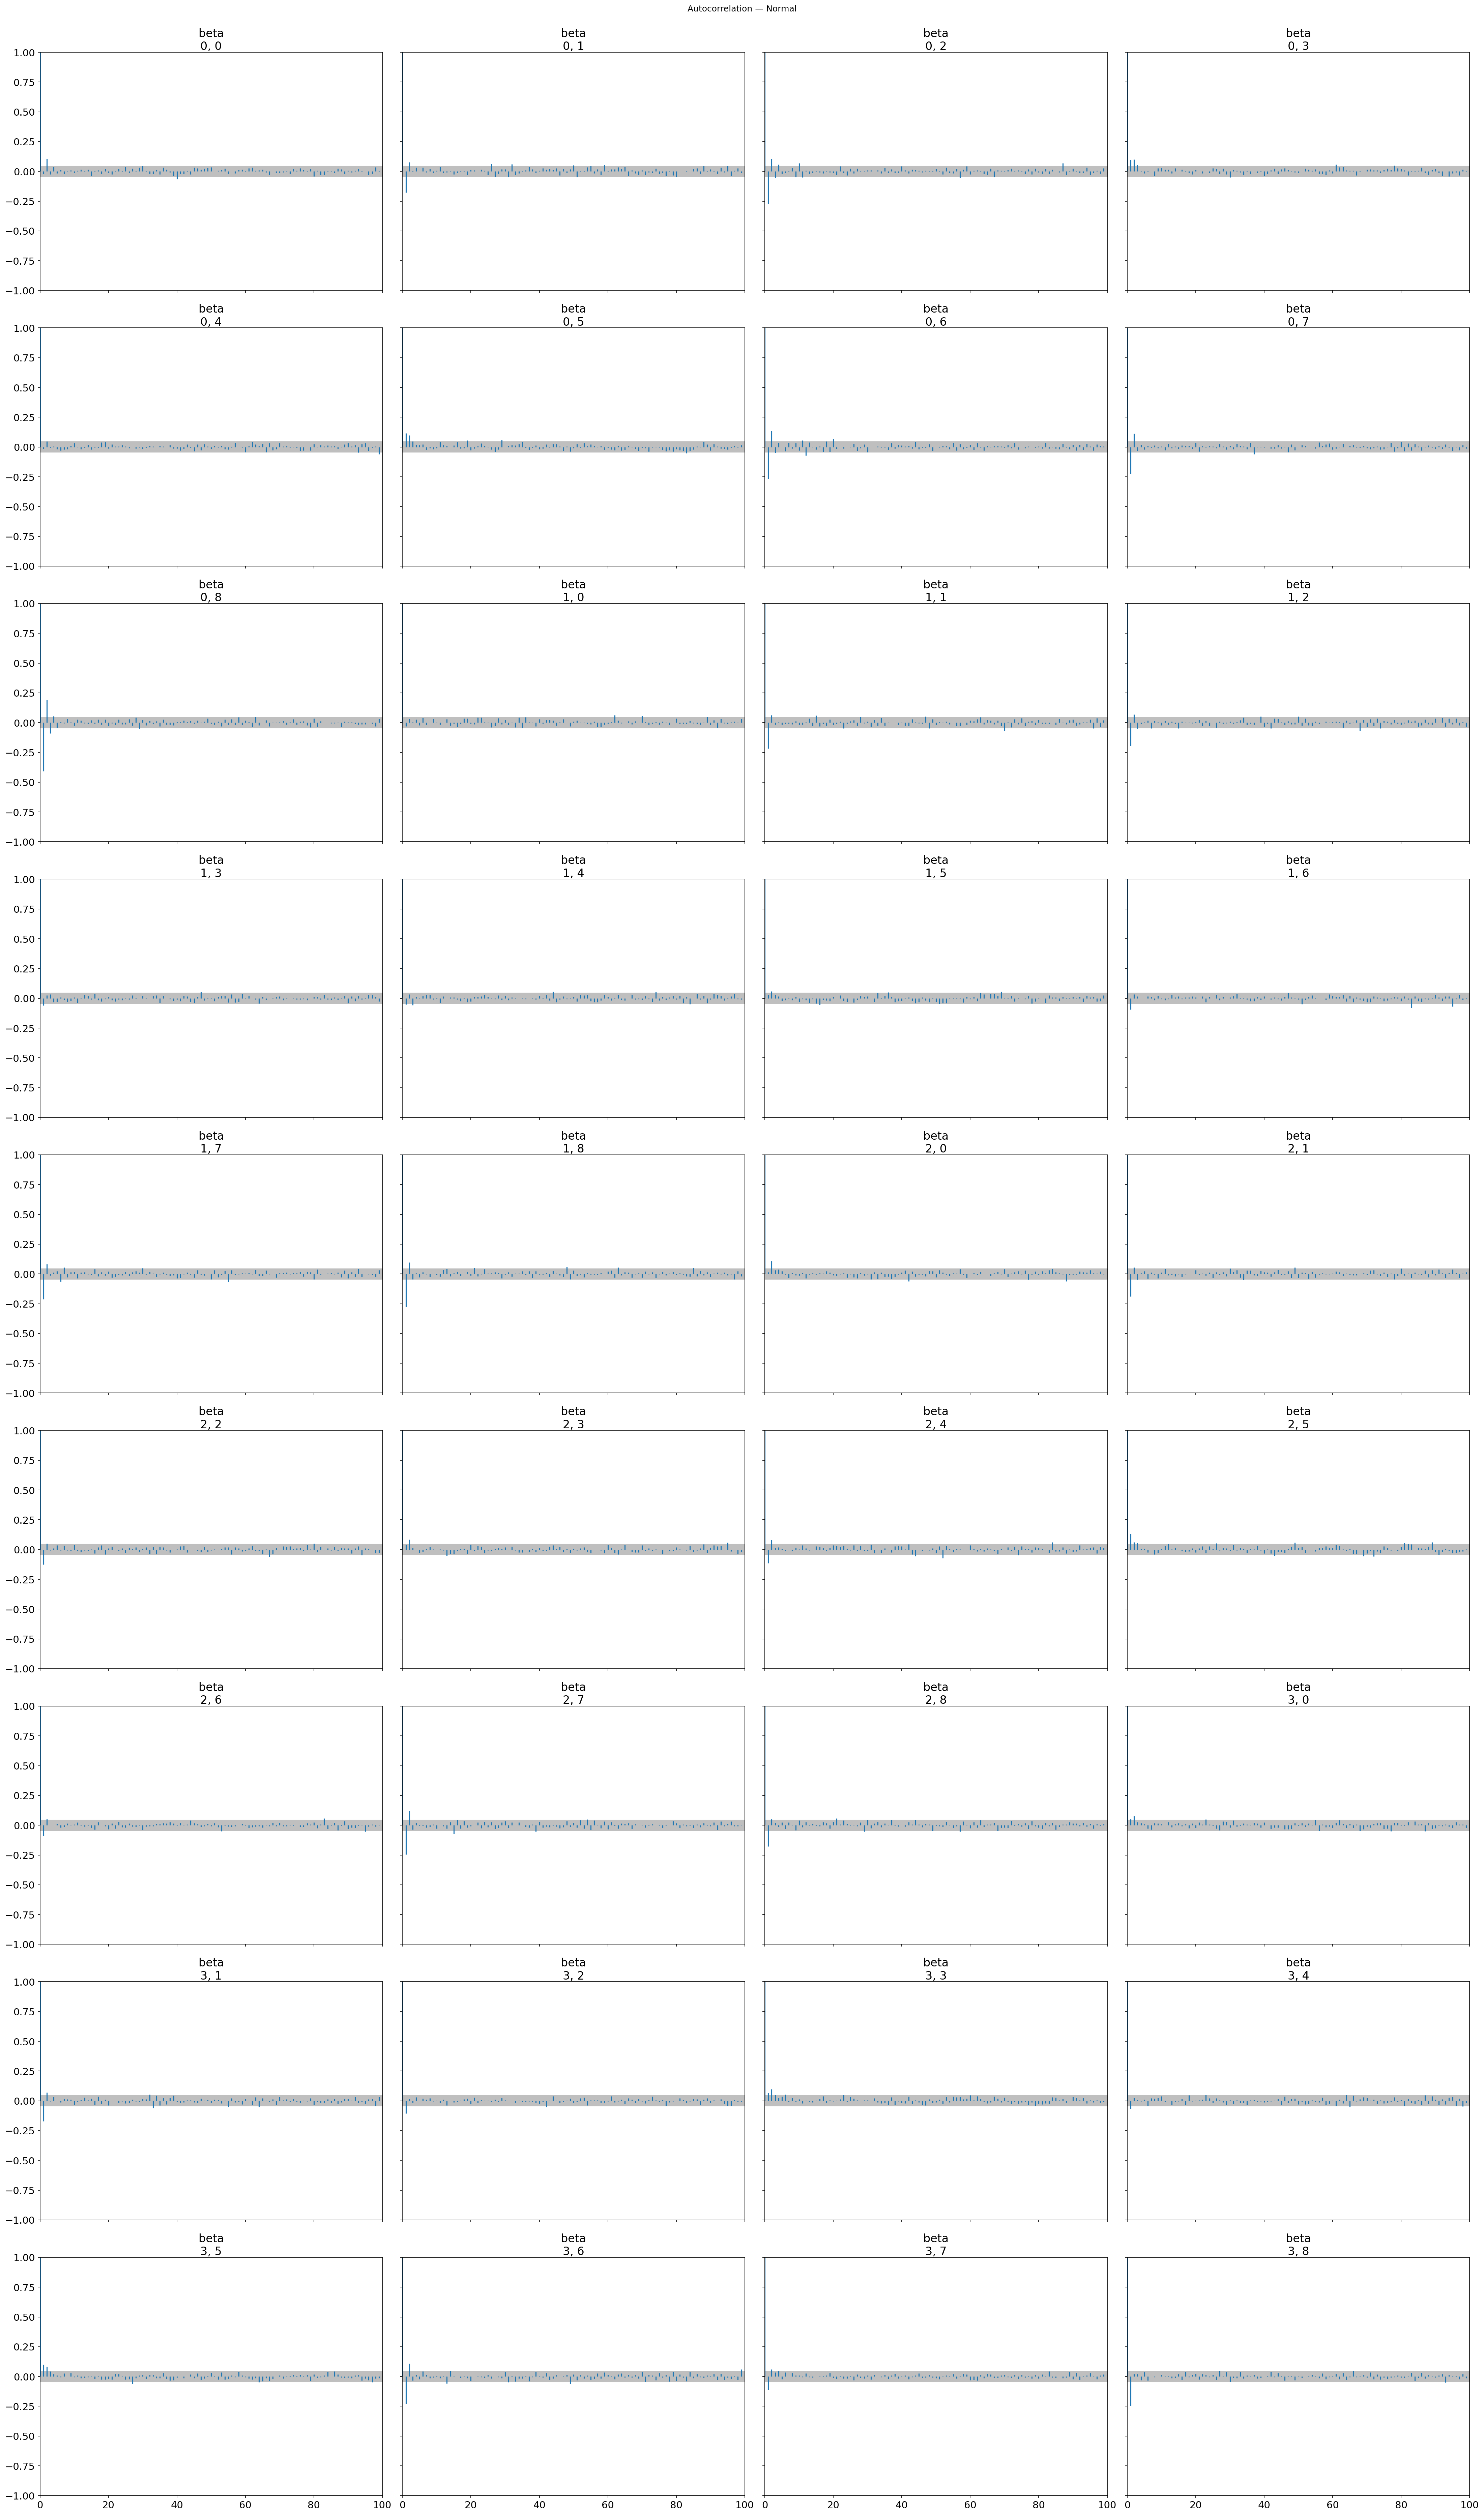

In [30]:
az.plot_autocorr(trace_h2_normal, var_names=['beta'])
plt.suptitle('Autocorrelation — Normal', y=1)
plt.tight_layout()
plt.show()

The autocorrelation plots for the Normal model show that correlation drops to
near zero immediately after lag 1 for all beta parameters. This means each
sample is essentially independent from the previous one, confirming that the
chains were mixing efficiently.

### (2) TruncatedNormal model diagnostics

#### Summary

In [31]:
summary_truncated = az.summary(trace_h2_truncated, var_names=['alpha', 'beta', 'sigma'])
summary_truncated

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],1.152,0.088,0.981,1.312,0.001,0.001,10437.0,6335.0,1.0
alpha[1],1.018,0.051,0.918,1.111,0.001,0.000,9747.0,5394.0,1.0
alpha[2],1.432,0.035,1.366,1.498,0.000,0.000,11528.0,5770.0,1.0
alpha[3],1.151,0.054,1.047,1.248,0.001,0.000,8589.0,6616.0,1.0
alpha[4],1.081,0.067,0.954,1.205,0.001,0.001,8675.0,6898.0,1.0
alpha[5],1.334,0.074,1.193,1.471,0.001,0.001,7084.0,5841.0,1.0
alpha[6],1.351,0.081,1.200,1.502,0.001,0.001,12175.0,6074.0,1.0
alpha[7],1.127,0.096,0.952,1.317,0.001,0.001,10277.0,5996.0,1.0
alpha[8],0.911,0.104,0.710,1.097,0.001,0.001,9529.0,6648.0,1.0
beta[0],0.282,0.109,0.079,0.487,0.001,0.001,8814.0,6547.0,1.0


The TruncatedNormal model also shows good sampling quality. All R-hat values
are exactly 1.0 and ESS values are well above 5000, despite the more complex
posterior geometry introduced by the truncation. The extra warmup iterations
(tune=4000) were sufficient to resolve the divergences we observed earlier.

#### Trace plots

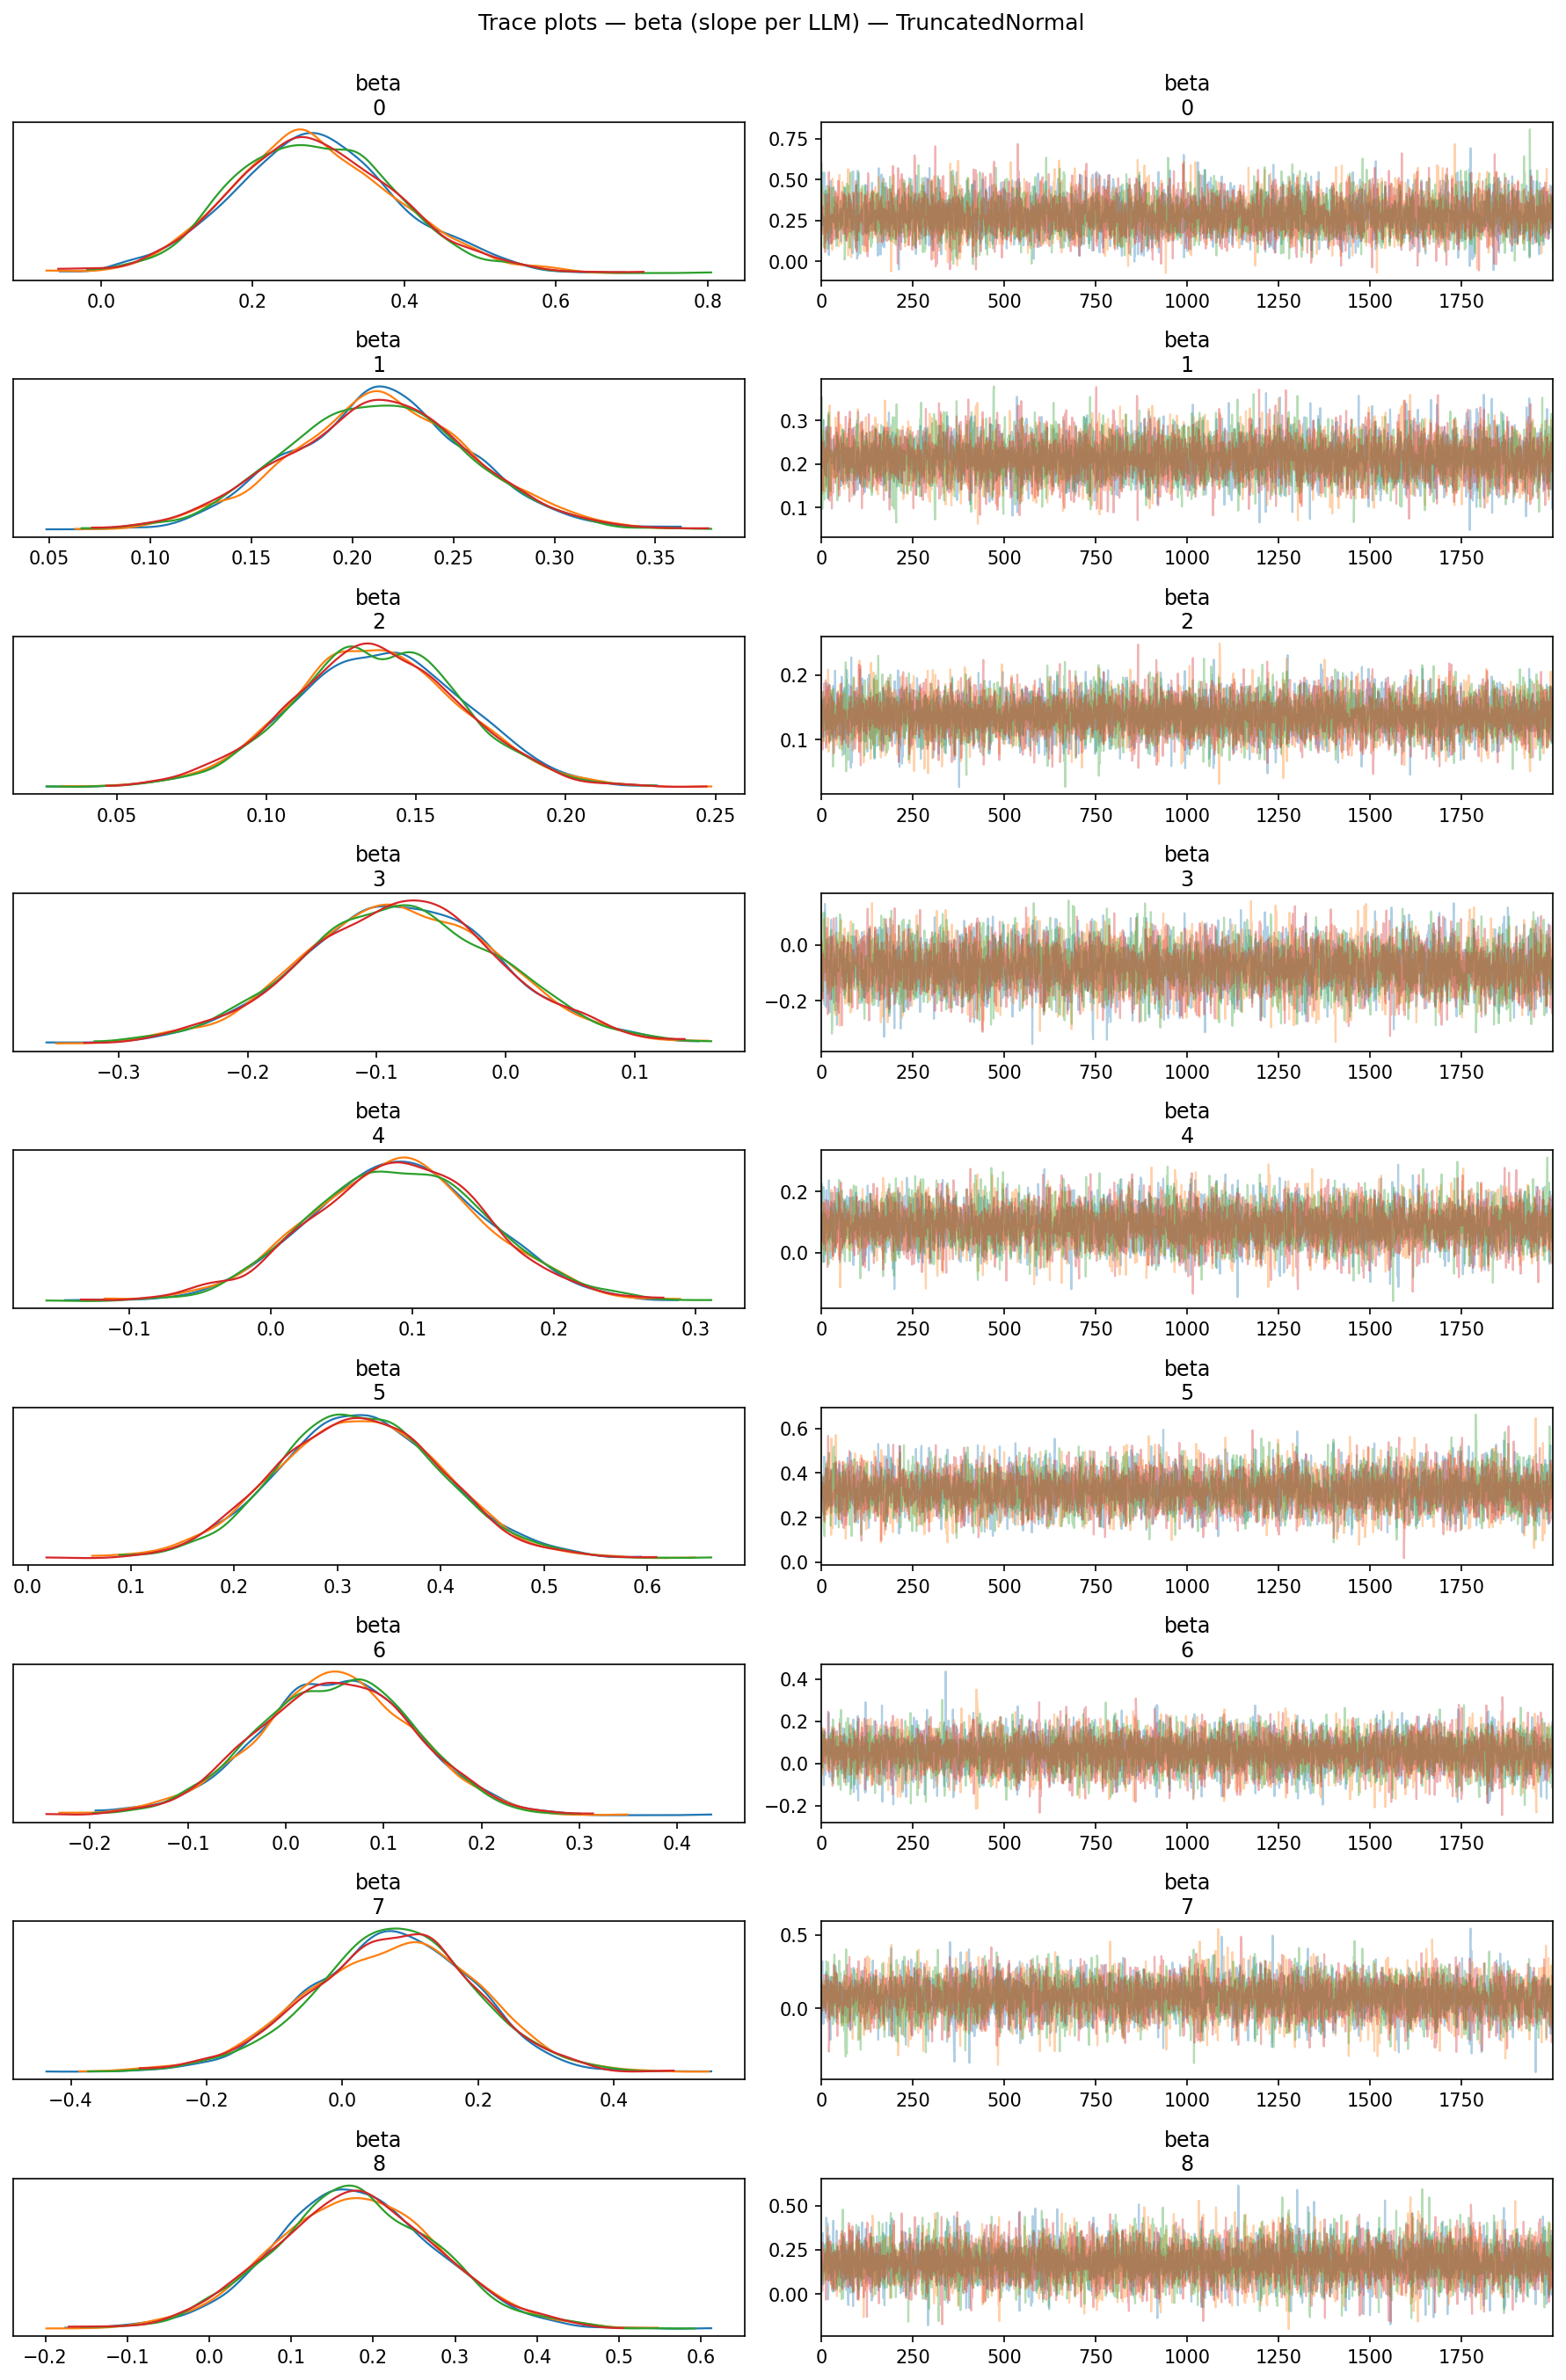

In [32]:
az.plot_trace(trace_h2_truncated, var_names=['beta'], compact=False)
plt.suptitle('Trace plots — beta (slope per LLM) — TruncatedNormal', y=1)
plt.tight_layout()
plt.show()

The TruncatedNormal model shows the same pattern. All 4 chains overlap well
on the left and the traces on the right look like random noise with no trends
or jumps. Despite needing more warmup to resolve divergences, the final
sampling quality is just as good as the Normal model.

#### Autocorrelation plots

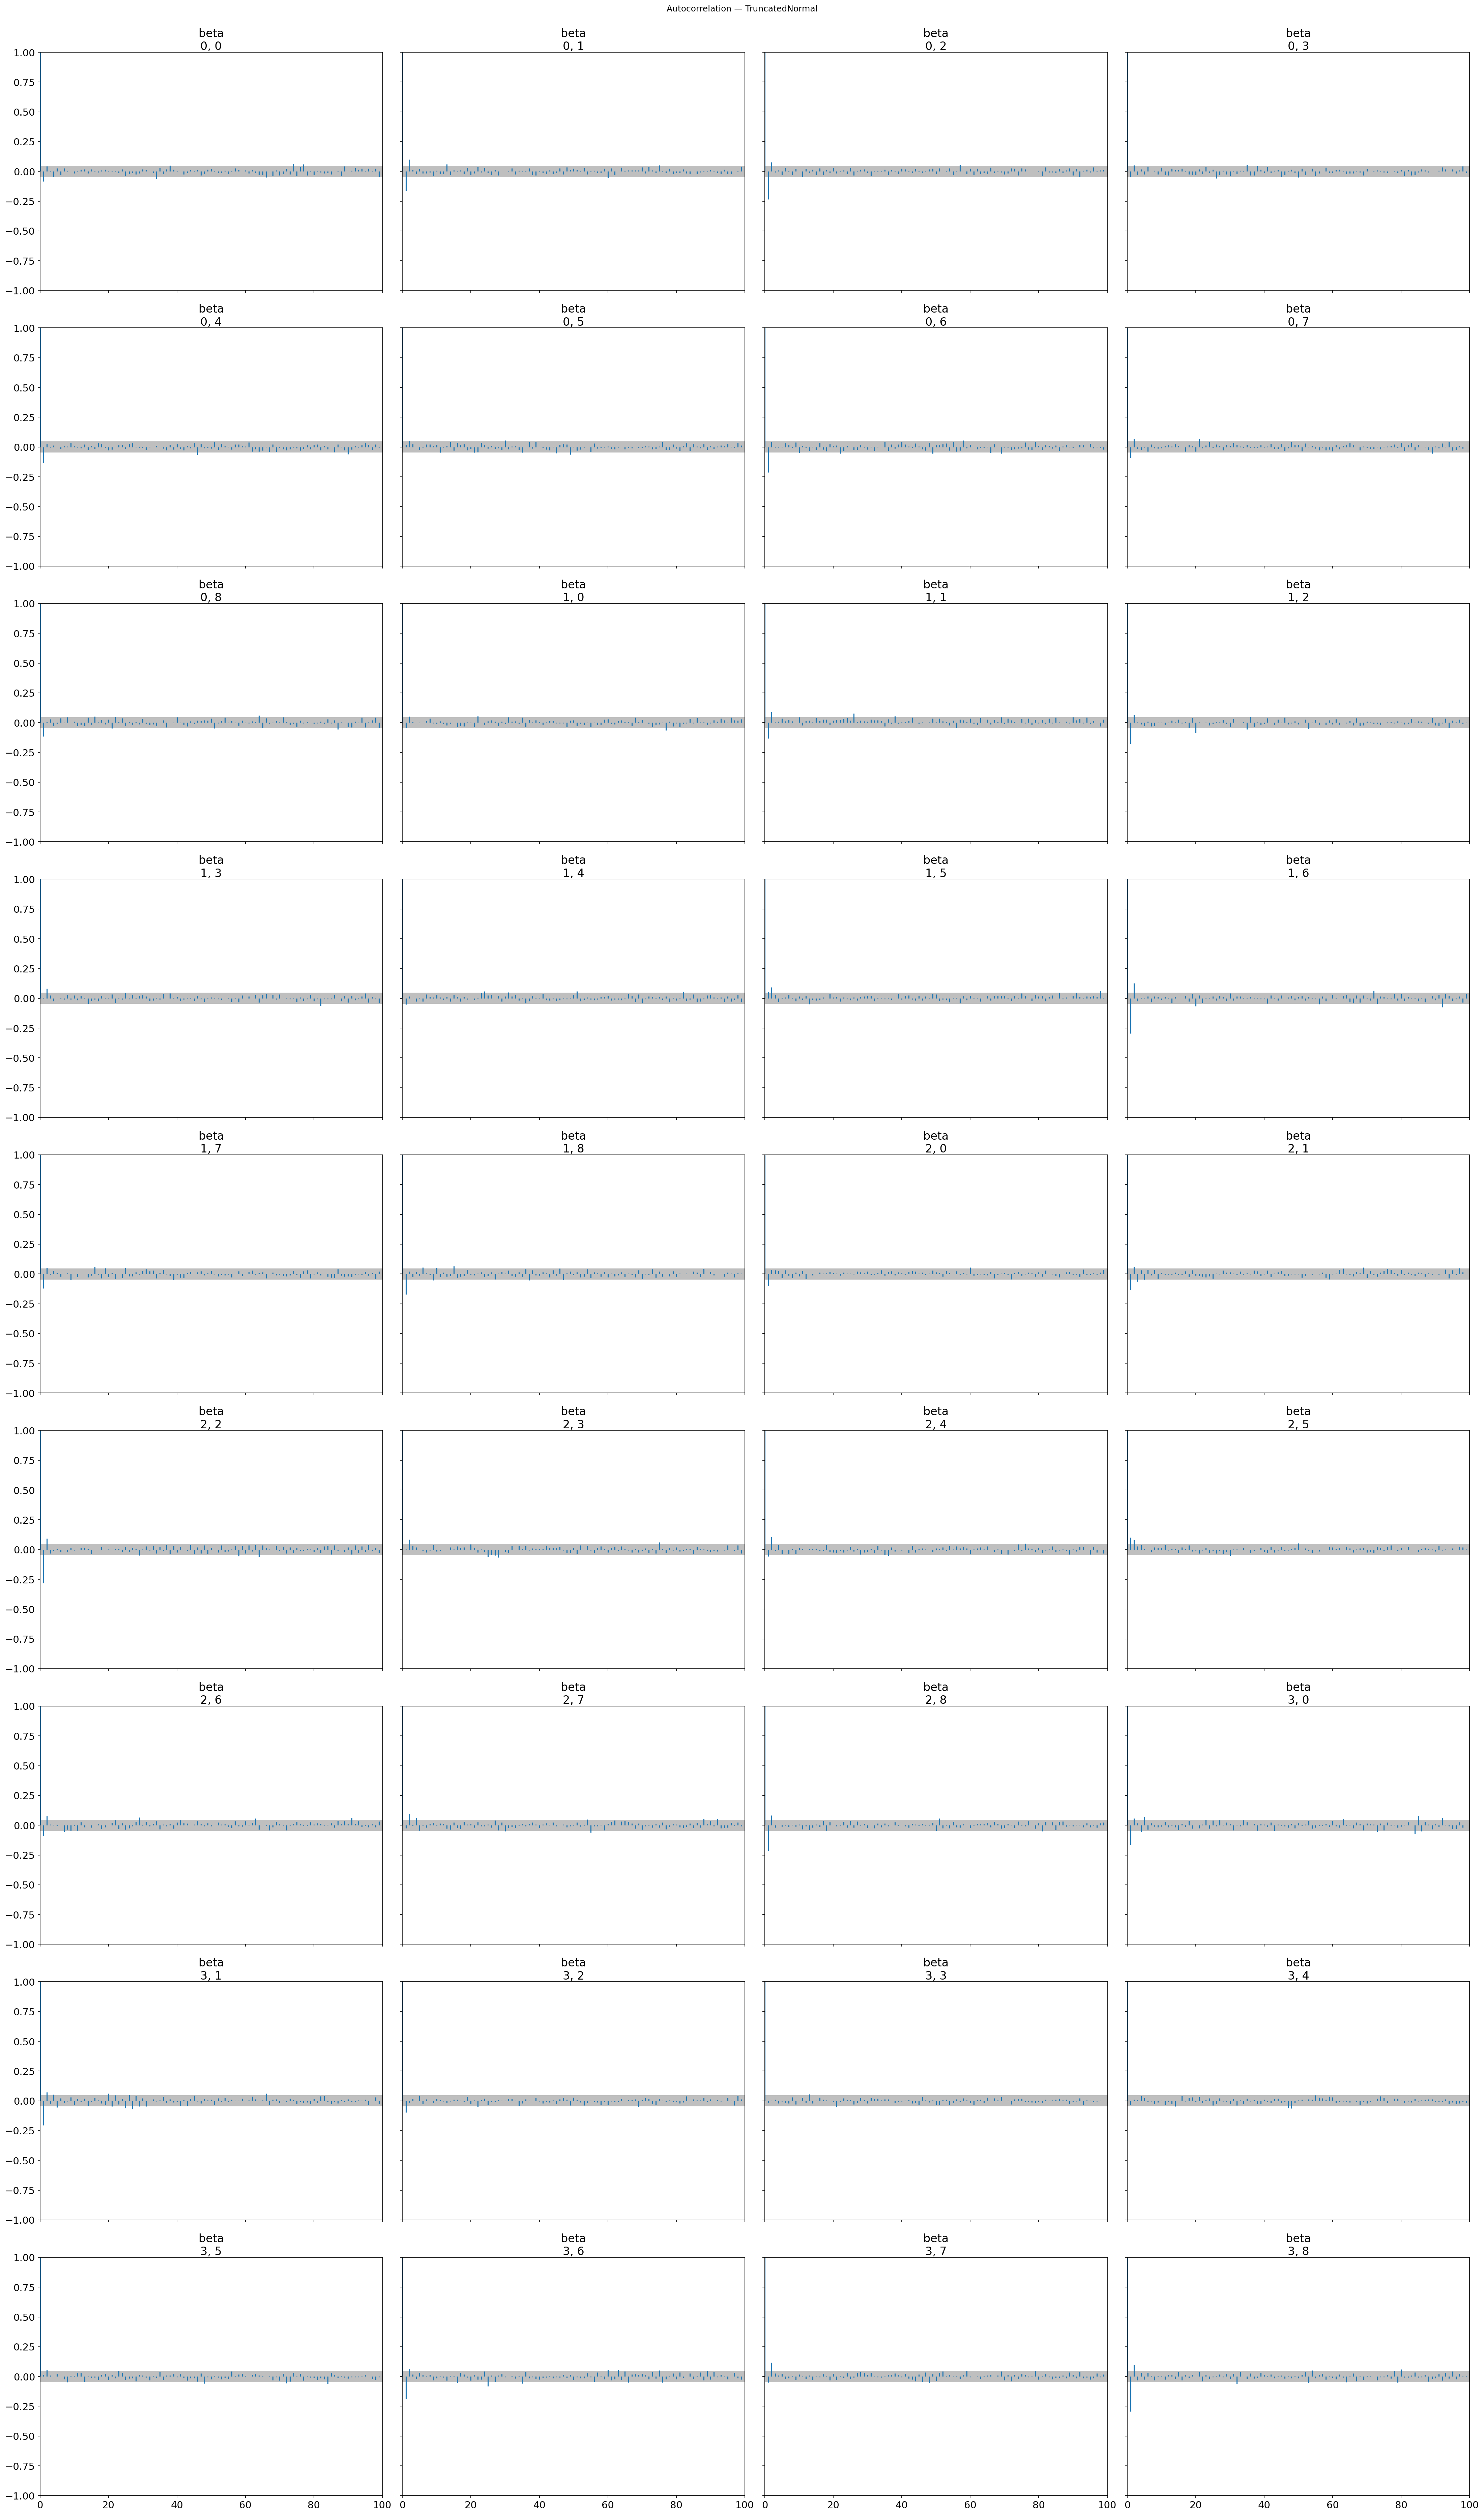

In [33]:
az.plot_autocorr(trace_h2_truncated, var_names=['beta'])
plt.suptitle('Autocorrelation — TruncatedNormal', y=1)
plt.tight_layout()
plt.show()

The TruncatedNormal model shows the same pattern — autocorrelation drops to
near zero immediately after lag 1 for all beta parameters. Despite the more
complex posterior geometry, the chains mixed just as efficiently as in the
Normal model.

## Posterior predictive check

We generate predictions from the fitted model and compare them to the actual
log(CC) values. If the two distributions overlap well, the model is a good
fit for the data.

Sampling: [log_cc_obs]


Output()

Sampling: [log_cc_obs]


Output()

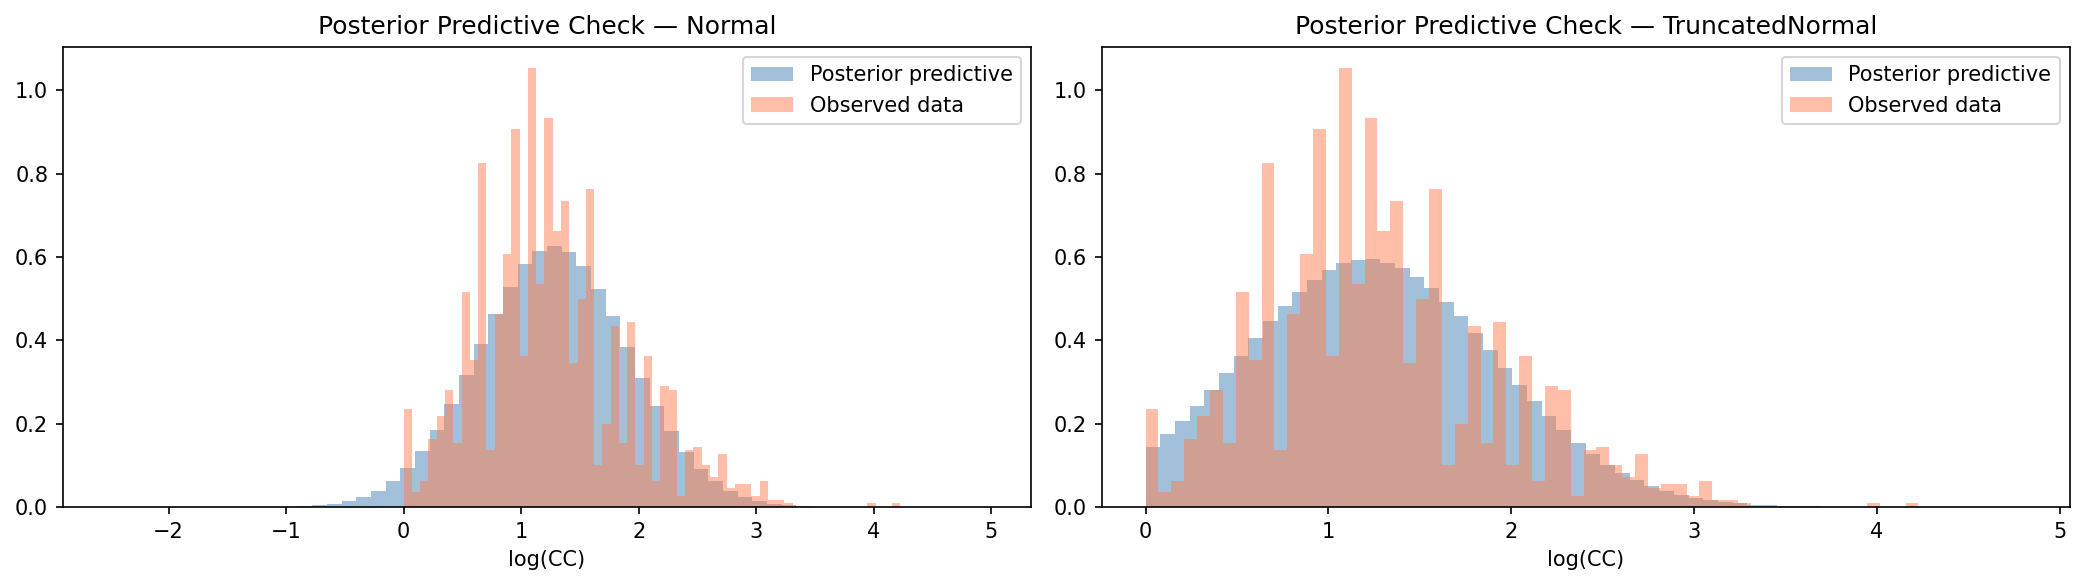

In [34]:
# Sample posterior predictive
with model_h2_normal:
    post_pred_normal = pm.sample_posterior_predictive(trace_h2_normal, random_seed=42)

with model_h2_truncated:
    post_pred_truncated = pm.sample_posterior_predictive(trace_h2_truncated, random_seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Normal model
axes[0].hist(
    post_pred_normal.posterior_predictive['log_cc_obs'].values.flatten(),
    bins=60, alpha=0.5, color='steelblue', label='Posterior predictive', density=True
)
axes[0].hist(
    log_cc_vals,
    bins=60, alpha=0.5, color='coral', label='Observed data', density=True
)
axes[0].set_xlabel('log(CC)')
axes[0].set_title('Posterior Predictive Check — Normal')
axes[0].legend()

# TruncatedNormal model
axes[1].hist(
    post_pred_truncated.posterior_predictive['log_cc_obs'].values.flatten(),
    bins=60, alpha=0.5, color='steelblue', label='Posterior predictive', density=True
)
axes[1].hist(
    log_cc_vals,
    bins=60, alpha=0.5, color='coral', label='Observed data', density=True
)
axes[1].set_xlabel('log(CC)')
axes[1].set_title('Posterior Predictive Check — TruncatedNormal')
axes[1].legend()

plt.tight_layout()
plt.show()

Both models reproduce the observed distribution of log(CC) well. The main
visible difference is that the Normal model extends slightly below zero,
while the TruncatedNormal model starts exactly at zero — consistent with
the constraint CC ≥ 1. Overall, both models fit the data well and we can
trust the posterior results from both.

## Hypothesis discussion

The main question is: is the slope β clearly positive for every LLM?
We visualize the posterior distributions of β using a forest plot and report
the mean and 95% HDI numerically.

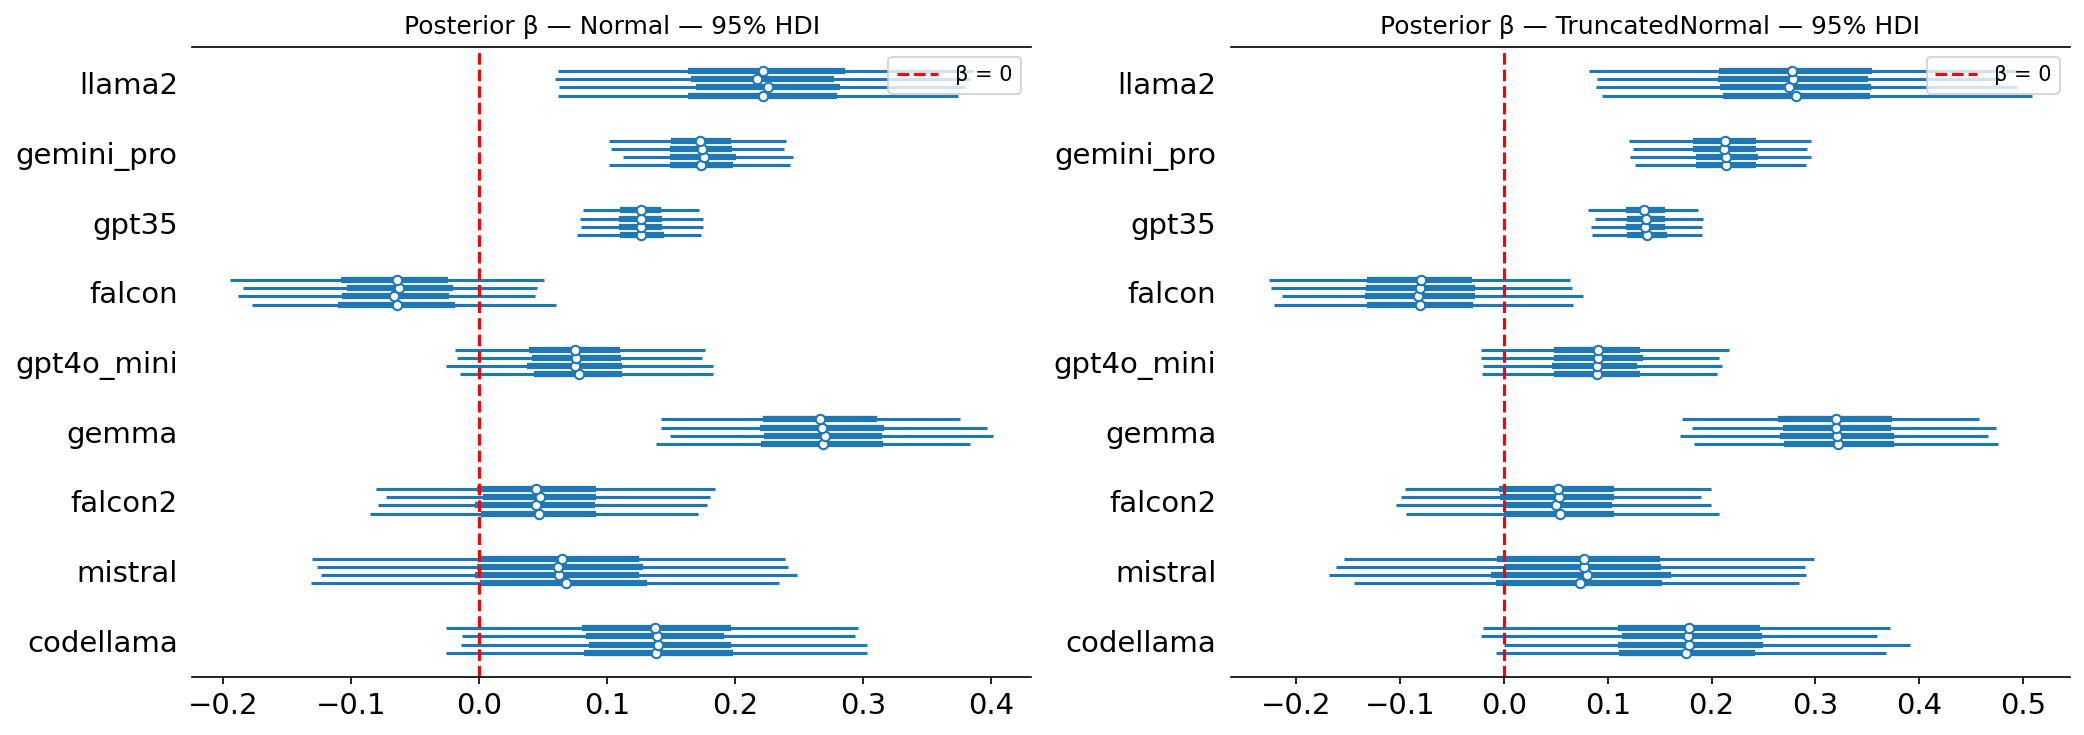

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Forest plot - Normal model
plt.sca(axes[0])
az.plot_forest(
    trace_h2_normal,
    var_names=['beta'],
    figsize=(7, 5),
    ax=axes[0]
)
axes[0].set_yticklabels(llm_names[::-1])
axes[0].axvline(0, color='red', linestyle='--', label='β = 0')
axes[0].set_title('Posterior β — Normal — 95% HDI')
axes[0].legend()

# Forest plot - Truncated model
plt.sca(axes[1])
az.plot_forest(
    trace_h2_truncated,
    var_names=['beta'],
    figsize=(7, 5),
    ax=axes[1]
)
axes[1].set_yticklabels(llm_names[::-1])
axes[1].axvline(0, color='red', linestyle='--', label='β = 0')
axes[1].set_title('Posterior β — TruncatedNormal — 95% HDI')
axes[1].legend()

plt.tight_layout()
plt.show()

### Normal model

In [36]:
beta_samples_normal = trace_h2_normal.posterior['beta'].values.reshape(-1, n_llms)

for i, llm in enumerate(llm_names):
    hdi = az.hdi(beta_samples_normal[:, i], hdi_prob=0.95)
    mean_beta = beta_samples_normal[:, i].mean()
    verdict = "✓ clearly positive" if hdi[0] > 0 else "✗ crosses zero"
    print(f"{llm:15s} | mean β = {mean_beta:.3f} | 95% HDI = [{hdi[0]:.3f}, {hdi[1]:.3f}] | {verdict}")

llama2          | mean β = 0.224 | 95% HDI = [0.056, 0.389] | ✓ clearly positive
gemini_pro      | mean β = 0.174 | 95% HDI = [0.102, 0.245] | ✓ clearly positive
gpt35           | mean β = 0.126 | 95% HDI = [0.079, 0.179] | ✓ clearly positive
falcon          | mean β = -0.065 | 95% HDI = [-0.186, 0.061] | ✗ crosses zero
gpt4o_mini      | mean β = 0.076 | 95% HDI = [-0.025, 0.183] | ✗ crosses zero
gemma           | mean β = 0.268 | 95% HDI = [0.140, 0.398] | ✓ clearly positive
falcon2         | mean β = 0.045 | 95% HDI = [-0.089, 0.181] | ✗ crosses zero
mistral         | mean β = 0.062 | 95% HDI = [-0.130, 0.255] | ✗ crosses zero
codellama       | mean β = 0.140 | 95% HDI = [-0.027, 0.305] | ✗ crosses zero


### TruncatedNormal model

In [37]:
beta_samples_truncated = trace_h2_truncated.posterior['beta'].values.reshape(-1, n_llms)

for i, llm in enumerate(llm_names):
    hdi = az.hdi(beta_samples_truncated[:, i], hdi_prob=0.95)
    mean_beta = beta_samples_truncated[:, i].mean()
    verdict = "✓ clearly positive" if hdi[0] > 0 else "✗ crosses zero"
    print(f"{llm:15s} | mean β = {mean_beta:.3f} | 95% HDI = [{hdi[0]:.3f}, {hdi[1]:.3f}] | {verdict}")

llama2          | mean β = 0.282 | 95% HDI = [0.082, 0.509] | ✓ clearly positive
gemini_pro      | mean β = 0.213 | 95% HDI = [0.125, 0.303] | ✓ clearly positive
gpt35           | mean β = 0.137 | 95% HDI = [0.081, 0.192] | ✓ clearly positive
falcon          | mean β = -0.081 | 95% HDI = [-0.229, 0.074] | ✗ crosses zero
gpt4o_mini      | mean β = 0.090 | 95% HDI = [-0.032, 0.210] | ✗ crosses zero
gemma           | mean β = 0.321 | 95% HDI = [0.169, 0.474] | ✓ clearly positive
falcon2         | mean β = 0.050 | 95% HDI = [-0.104, 0.205] | ✗ crosses zero
mistral         | mean β = 0.072 | 95% HDI = [-0.169, 0.303] | ✗ crosses zero
codellama       | mean β = 0.179 | 95% HDI = [-0.027, 0.378] | ✗ crosses zero


## Overall conclusion

**H2 is not supported.**

Both models agree on the same result. Out of 9 LLMs, only 4 show a clearly
positive relationship between LOC and CC: llama2, gemini_pro, gpt35, and
gemma. For the remaining 5 LLMs — falcon, gpt4o_mini, falcon2, mistral, and
codellama — the 95% HDI crosses zero, meaning we cannot conclude that longer
code leads to higher cyclomatic complexity for those models. Falcon even has
a negative mean β in both models.

Since both models lead to the same conclusion, the result is robust. The
hypothesis requires the relationship to hold for all LLMs, which it does not.

# General conclusion (whole task)

Overall, the analysis suggests that vulnerability generation differs across LLMs, with llama2 generally producing safer code than most competing models, thus making the hypothesis partially supported. However, the relationship between program size and cyclomatic complexity was not consistently present across all LLMs, indicating that code complexity patterns vary substantially between models.

# Generative AI statement

Generative AI was used to assist with coding tasks such as creating plots, working with libraries, and restructuring data when needed, for example when setting the llama2 LLM as the reference category. Additionally, it was used to support text restructuring and grammar checking.

The theoretical part of this report is based on material covered in the course, including concepts learned through lectures and the course literature. The development and interpretation of the models were therefore primarily based on our own understanding and knowledge gained from these sources.